In [1]:
import sys
from pyprojroot import here

sys.path.insert(0, str(here()))

import pandas as pd
import numpy as np
import xarray as xr
import pickle
import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
import pymc_extras as pmx
import geopandas as gpd

import pandas_datareader.data as pdr
import datetime

from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve

from libpysal.weights import KNN, fuzzy_contiguity, w_union, W
import networkx as nx
import warnings

import os
from os.path import exists

import pathlib
from cycler import cycler

import pytensor
from laos_gggi.model import add_data
from laos_gggi.plotting import configure_plot_style

from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data, process_ipcc_scenarios


config = {
    'figure.figsize':(14,4),
    'figure.constrained_layout.use':True,
    'figure.facecolor':'w',
    'axes.grid':False,
    'grid.linewidth':0.5,
    'grid.linestyle':'--',
    'axes.spines.top':False,
    'axes.spines.bottom':False,
    'axes.spines.left':False,
    'axes.spines.right':False
}

plt.rcParams.update(config)


SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [2]:
from laos_gggi import load_shapefile
from laos_gggi.replication_data import create_replication_data
from laos_gggi.data_functions import load_emdat_data, load_all_data
from laos_gggi.sample import sample_or_load

In [3]:
OECD_colors = ["#002F6C", "#7FA8D9", "#006BB6", "#00AACC", "#82D2E3"]
OECD_cycler = cycler(color=OECD_colors)

In [4]:
plt.rcParams.update(
    {
        "axes.prop_cycle": OECD_cycler,
    }
)

# Event data

In [5]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [6]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

# Helper functions

In [7]:
def damage_plot(iso, idata, df = None, cls='hydro', group='posterior_predictive', var_name = 'y_hat'):
    fig, ax = plt.subplots()
    data = idata[group][var_name].sel(obs_iso=iso, obs_disaster_class=cls).groupby('obs_year').mean()
    if df is not None:
        targets = df.query('iso == @iso & disaster_class == @cls').groupby('year')['Total_Damage_Adjusted'].mean().resample('YS').last()
        ax.scatter(targets.index, targets.values, color='tab:red', zorder=100)
    mu = data.quantile(0.5, dim=['chain', 'draw']).to_dataframe()[var_name].resample('YS').last()

    hdi_80 = az.hdi(data, hdi_prob=0.8)[var_name].to_dataframe()[var_name].unstack('hdi').resample('YS').last()
    hdi_94 = az.hdi(data)[var_name].to_dataframe()[var_name].unstack('hdi').resample('YS').last()

   
    ax.scatter(mu.index, mu.values, s=70)

    ax.vlines(mu.index, *hdi_80.values.T, lw=3)
    ax.vlines(mu.index, *hdi_94.values.T)
    ax.grid(ls='--', lw=0.5)
    # ax.set(title = f'{iso} - {cls}')
    plt.show()

In [8]:
def plot_predictions(idata, 
                     iso: str,
                     group: str = 'posterior_predictive',
                     var_name: str = 'y_hat',
                     obs_name: str | None = None,
                     data: pd.DataFrame | None = None,
                     **kwargs):
    if group not in ['prior', 'posterior', 'prior_predictive', 'posterior_predictive']:
        raise ValueError(f'Invalid group {group}')
    
    if obs_name and data is None:
        obs_df = idata.observed_data.sel(obs_iso=iso)[obs_name].to_dataframe()[obs_name].drop_duplicates().unstack('disaster')
    elif data is not None:
        obs_df = data.xs(level=0, key=iso)
        
    iso_idata = idata[group][var_name].sel(obs_iso = iso)
    mu = iso_idata.mean(dim=['chain', 'draw'])
    
    index = mu['obs_year'].values
    disasters = mu['disaster'].values
    
    fig, ax = plt.subplots(1, 2, **kwargs)
    
    for disaster, axis in zip(disasters, fig.axes):
        axis.plot(index, mu.sel(disaster=disaster).values, color='tab:blue')

        if obs_name:
            axis.plot(index, obs_df[disaster].values, color='k', marker='o')
    
        for hdi_prob in np.linspace(0.05, 0.95, 25)[::-1]:
            hdi = az.hdi(iso_idata.sel(disaster=disaster), hdi_prob=hdi_prob)[var_name]
            axis.fill_between(index, *hdi.values.T, color='tab:blue', alpha=0.1)
        # axis.set(xlabel="Year", ylabel = "Disaster Count", title=f"{iso} {disaster.title()}")

    plt.show();

In [9]:
def plot_predictions_2(idata, 
                     iso: str,
                     group: str = 'posterior_predictive',
                     var_name: str = 'y_hat',
                     obs_name: str | None = None,
                     data: pd.DataFrame | None = None,
                    disaster : str ='hydro',
                     **kwargs):
    if group not in ['prior', 'posterior', 'prior_predictive', 'posterior_predictive']:
        raise ValueError(f'Invalid group {group}')
    
    if obs_name and data is None:
        obs_df = idata.observed_data.sel(obs_iso=iso)[obs_name].to_dataframe()[obs_name].drop_duplicates().unstack('disaster')
    elif data is not None:
        obs_df = data.xs(level=0, key=iso)
    
    iso_idata = idata[group][var_name].sel(obs_iso = iso)
    mu = iso_idata.mean(dim=['chain', 'draw'])
    
    index = mu['obs_year'].values
    
    fig, ax = plt.subplots(1, 1,)
    
    for axis in fig.axes:
        axis.plot(index, mu.sel(disaster=disaster).values, color='#0073cc')
    
        if obs_name:
            axis.plot(index, obs_df[disaster].values, color='k', marker='o')
    
        for hdi_prob in [0.95]:
            hdi = az.hdi(iso_idata.sel(disaster=disaster), hdi_prob=hdi_prob)[var_name]
            axis.fill_between(index[37:], *hdi.values[37:].T, color='#0073cc', alpha=0.1, label ="95% High Density Interval")
        # axis.set(xlabel="Year", ylabel = "Disaster Count", title=f"{iso} {disaster.title()}")
    axis.legend()
    plt.show();

In [10]:
def ppc_plot(iso, classes, 
             idata=None,
             predictions=None,
             group='posterior', 
             target='y_hat',
             hdi_lim=1.0):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    
    if idata is None and predictions is None:
        raise ValueError('Need at least one of idata or predictions')
    
    for cls, axis in zip(classes, fig.axes):
        sel = {'obs_iso': iso, 'obs_disaster_class':cls}

        if predictions is None:
            pp = idata[f'{group}_predictive'].sel(obs_iso = iso)
        else:
            pp = predictions['predictions'].sel(obs_iso = iso)
        
        if cls not in pp.coords['obs_disaster_class']:
            axis.set_title(cls)
            continue
        else:
            pp = pp.sel(obs_disaster_class = cls)
        
        if idata is not None:
            obs = idata.observed_data.sel(obs_iso = iso)
            observed = True
        if cls not in obs.coords['obs_disaster_class']:
            obs = pp.copy().mean(dim=['chain', 'draw']) # Dummy data, otherwise plot_ppc throws a fit
            observed=False
        else:
            obs = obs.sel(obs_disaster_class = cls)
        
        pp[target] = pp[target] + np.random.uniform(0, 1e-6, size=pp[target].values.shape)
        
        az.plot_ppc(az.InferenceData(posterior_predictive=pp,
                                     observed_data=obs),
                    ax=axis,
                    var_names=target,
                    observed=observed,
                    legend=False)
            
        # axis.set_title(cls)
        
        if hdi_lim < 1.0:
            hdi = az.hdi(pp, hdi_prob=hdi_lim)[target]
            higher = hdi.sel(hdi = 'higher').max()
            axis.set_xlim(0, higher)


### Damage curves model

In [11]:
# Importing cpi data
import pandas as pd
import pandas_datareader.data as pdr
import datetime

# Define the CPI series code for the US
cpi_series_code = 'CPIAUCNS'

# Define the date range
start_date = datetime.datetime(1913, 1, 1)  # CPI data starts from 1913
end_date = datetime.datetime(2025, 12, 31)  # Assuming we want data up to 2025

# Fetch CPI data from FRED
cpi_data = pdr.get_data_fred(cpi_series_code, start_date, end_date)

# Display the fetched data
cpi_2015 = cpi_data.loc['2015-12-01']['CPIAUCNS']
cpi_2025 = cpi_data.loc['2025-01-01']['CPIAUCNS']


In [12]:
def curves_model( coords, df , 
                 codes_idx_joint, 
                 features_events,
                 damage_features_d_stand, 
                 class_idx_joint):
    
    with pm.Model(coords = coords) as model:
        ######################################## event model ########################################
        X_event = pm.Data('X', df[features_events])
        iso_idx_pt = pm.Data('iso_idx', codes_idx_joint, dims=['obs_idx'])
    
        latent_iso_events = pm.Flat('latent_iso_events', dims=['iso', 'features_events'])
        
        # Actual Model    
        country_loc = pm.Flat('country_loc', dims=['disaster'])
        country_scale = pm.Flat('country_scale',dims=['disaster'])
        country_offset = pm.Flat('country_offset', dims=['iso', 'disaster'])
    
        country_effect = pm.Deterministic('country_effect',
                                          country_loc[None] + country_scale[None] * country_offset, 
                                          dims=['iso', 'disaster'])
        
        
        # beta_sigma = 2.5 / df_joint[features_events].std().values[None] * df[disasters].std().values[:, None]
        beta = pm.Flat('beta', dims=['features_events', 'disaster'])
        beta_GY = pm.Flat('beta_GY', dims=['features_events', 'disaster'])    
        coef_effect = X_event @ beta + (latent_iso_events @ beta_GY)[iso_idx_pt]
        mixture = pm.Flat("mixture",
                                   dims = ["iso", 'disaster'])
    
        latent_rate = (country_effect + mixture)[iso_idx_pt] + coef_effect
        mu = pt.softplus(latent_rate)
        
        zero_prob = pm.Flat('zero_prob',dims=['disaster'])
        alpha = pm.Flat('alpha',dims=['disaster'])
        
        y_hat_n_events = pm.ZeroInflatedNegativeBinomial('y_hat_n_events',
                                                psi=zero_prob,
                                                mu=pt.clip(mu, 1e-6, 300),
                                                alpha=alpha,
                                                observed = np.zeros((df.shape[0],2)),
                                                dims= ['obs_idx', 'disaster'])
    
        ######################################## Damages model ########################################
        X_damage = pm.Data('X_damage',   df[damage_features_d_stand], 
                dims=['obs_idx', 'features_damages'])
    
        
        class_idx_pt = pm.Data('class_idx', class_idx_joint, dims=['obs_idx'])
        
        latent_iso_damage = pm.Flat('latent_iso_damage', dims=['iso', 'features_damages'])
        
        country_loc_damage = pm.Flat('country_loc_damage',  dims=['disaster'])
        country_scale_damage = pm.Flat('country_scale_damage', dims=['disaster'])
        country_offset_damage = pm.Flat('country_offset_damage', dims=['iso', 'disaster'])
        country_effect_damage = pm.Deterministic('country_effect_damage', 
                                                 country_loc_damage + country_scale_damage * country_offset_damage,
                                          dims=['iso', 'disaster'])
    
        
        
        beta_damage = pm.Flat('beta_damage', dims=['features_damages', 'disaster'])
        beta_GY_damage = pm.Flat('beta_GY_damage', dims=['features_damages', 'disaster'])    
        coef_effect_damage = X_damage @ beta_damage + (latent_iso_damage @ beta_GY_damage)[iso_idx_pt]
    
        mixture_damage = pm.Flat("mixture_damage",
                                   dims = ["iso", 'disaster'])
    
        mu = ((country_effect_damage + mixture_damage)[iso_idx_pt] + coef_effect_damage)

        # We transform the mus back to 2015 USD 
        mu = (mu /(cpi_2025 / cpi_2015))
        
    
        sigma = pm.Flat('sigma', dims=['disaster'])

        
        mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
        mu_damage = pm.Deterministic('mu_damage', pt.concatenate(mus, axis=0), dims=['obs_idx'])
        
        p_zero_damage = pm.Flat('p_zero_damage',dims=['disaster'])
        y_hat_damages = pm.HurdleLogNormal('y_hat_damages',
                       mu=mu_damage,
                       sigma= sigma[class_idx_pt],
                       psi=(1 - p_zero_damage)[class_idx_pt],
                       observed = np.zeros((df.shape[0],)) ,
                       dims=['obs_idx'])
    
        #################################### Damage curves ####################################
        damages_curves = pm.Deterministic("damages_curves", y_hat_damages * y_hat_n_events[: ,1], dims=['obs_idx'])

    return model

### Points model

In [13]:
def points_model(model, df, ISO_idx, obs_idx, beta_point_features ):
    with model.copy() as temp_model:
        #Declare data
        pm.set_data({"X_gp": df[["lat", "long"]],
                     "Y": np.full( df.shape[0], 0 ),
                     "X": df[beta_point_features],
                     "ISO_idx_pt": ISO_idx
     
                },
            coords= {"obs_idx": obs_idx } 
           )
    
        y_hat_invlogit = pm.Deterministic('y_hat_invlogit', pm.math.invlogit(temp_model["y_hat"] ))

        HSGP_component_invlogit = pm.Deterministic('HSGP_component_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
        
        # River effect
        river_effect = pm.Deterministic('river_effect', temp_model["beta_points"][0] *df['log_distance_to_river__standardized'])
        # Coast effect
        coast_effect = pm.Deterministic('coast_effect',  temp_model["beta_points"][1] * df['log_distance_to_coastline__standardized'])

        #changing_betas_effect
        changing_betas_effect = pm.Deterministic('changing_betas_effect', 
                                                 ( temp_model['beta_points'][2:] @ df[time_varying_features].T  )  )

    return temp_model

# Return years functions

In [14]:
from scipy import interpolate


def obtain_base_table(idata, posterior_predictive_input = False):
    computed_ry_damage = {}
    curves_df = pd.DataFrame( )
    
    for year in curve_years:
        damages = idata.posterior_predictive.damages_curves.sel(obs_iso='LAO',obs_year = year).values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys =   np.repeat(100, 10000) /np.linspace(0, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array( [1, 2, 2.5, (10/3), 4, 5,  10, 25, 50, 75] ) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year.year
        computed_ry_damage[year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df = pd.concat([curves_df,computed_ry_damage[year_].T], axis=1)
        
    curves_df= curves_df.reset_index()
    curves_df = curves_df.assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df = curves_df.sort_index(ascending= True)

    return curves_df, percentile


    # Build the return years table
def build_return_years_curve(curves_df ):
    return_years_table = curves_df.loc[np.repeat(100,10)- percentile[-10:]].drop_duplicates()
    
    return_years_table = return_years_table.assign( value = lambda x: (100 / x['percentile_inv']).round(decimals = 1) ) 
    return_years_table = (return_years_table.assign(
        return_years = lambda x:  x['value'].round(0).astype(int).astype(str)  + ' RY' )
                          .drop(columns = ['value', 'percentile_inv']).set_index('return_years',  ))
    return return_years_table

## Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [15]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "square_ln_gdp_pc", 
            "precip_deviation", 
            "co2", 
            "population"]

In [16]:
df.dropna(subset=features, inplace=True)

In [17]:
events_idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'year': 'obs_year', 'iso': 'obs_iso'} ), dim= "obs_idx" )

## Reconcile EMDAT and shapefile ISO codes

In [18]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world.index.unique()

In [19]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [20]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'SGP, AIA, SGS, VCT, JAM, QAT, DMA, ASM, MSR, ATF, SMR, GUM, GRL, CYM, SHN, HKG, VIR, SXM, FSM, LIE, MNP, NIU, NRU, STP, LCA, BRB, MAC, GIB, BLM, HMD, TUV, SYC, MCO, GGY, BHS, SPM, MLT, SLB, TTO, LUX, CPV, ABW, UNK, PCN, IOT, AND, COM, BHR, COK, PLW, MHL, MAF, ISR, BMU, KNA, PSE, WLF, FRO, CUW, PRI, NFK, PRK, KIR, IMN, VEN, FLK, VAT, GRD, VGB, TCA, JEY, TON, MDV, ATG, CYP'

In [21]:
# Drop codes not in both
common_codes = set(world_iso).intersection(set(df_iso))

df = df.query('iso in @common_codes').copy()
world = world.query('iso in @common_codes').copy()

In [22]:
# Get unique iso codes and years
code_idx, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)

In [23]:
y = df[disasters].copy().astype(float)

# Assume years without observed disasters had no disasters.
# **THIS IS A TERRIBLE ASSUMPTION **
# but sampling is too onerous without it.
y_filled = y.fillna(0)

# Damage data

In [24]:
emdat = load_emdat_data()

In [25]:
emdat['df_raw'].query('ISO == "LAO"').shape

(62, 47)

In [26]:
emdat['df_raw'].rename(columns = {'Disaster Subgroup': 'subgroup'}).query('subgroup == "Hydrological" ')['Disaster Type']

2                      Flood
22                     Flood
23                     Flood
92       Mass movement (wet)
93                     Flood
                ...         
26639                  Flood
26640                  Flood
26641                  Flood
26647                  Flood
26649    Mass movement (wet)
Name: Disaster Type, Length: 6846, dtype: object

In [27]:
emdat['df_raw'].rename(columns = {'Disaster Subgroup': 'subgroup'}).query('subgroup == "Hydrological" ')['Disaster Type']

2                      Flood
22                     Flood
23                     Flood
92       Mass movement (wet)
93                     Flood
                ...         
26639                  Flood
26640                  Flood
26641                  Flood
26647                  Flood
26649    Mass movement (wet)
Name: Disaster Type, Length: 6846, dtype: object

In [28]:
emdat['df_raw'].query('ISO == "LAO"')

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,Reconstruction_Costs_Adjusted,Insured_Damage,Insured_Damage_Adjusted,Total_Damage,Total_Damage_Adjusted,CPI,Admin Units,Entry Date,Last Update,disaster_class
1588,1966-0064-LAO,Yes,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,LAO,...,NaN,NaN,NaN,15300.0,143628.0,10.652497,NaN,2003-07-01,2023-09-25,Hydrometereological
1785,1968-0072-LAO,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,LAO,...,NaN,NaN,NaN,1280.0,11213.0,11.415537,NaN,2003-07-01,2023-09-25,Hydrometereological
1860,1969-0086-LAO,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,LAO,...,NaN,NaN,NaN,NaN,NaN,12.039097,NaN,2003-07-01,2023-09-25,Hydrometereological
2054,1971-0048-LAO,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,LAO,...,NaN,NaN,NaN,200.0,1505.0,13.288956,NaN,2003-07-01,2023-09-25,Hydrometereological
2720,1977-9029-LAO,Yes,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,LAO,...,NaN,NaN,NaN,NaN,NaN,19.891037,NaN,2006-02-13,2023-09-25,Climatological
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24470,2020-0411-LAO,No,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,GLIDE:FL-2020-000211,Tropical storm Linfa,LAO,...,NaN,NaN,NaN,NaN,NaN,84.939198,"[{""adm1_code"":1763,""adm1_name"":""Salavan""},{""ad...",2020-10-13,2023-09-25,Hydrometereological
24881,2021-0327-LAO,No,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,Tropical storm 'Koguma',LAO,...,NaN,NaN,NaN,NaN,NaN,88.929493,"[{""adm1_code"":1765,""adm1_name"":""Xaignabouli""}]",2021-07-09,2023-09-25,Hydrometereological
25208,2021-0829-LAO,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,LAO,...,NaN,NaN,NaN,120.0,135.0,88.929493,"[{""adm1_code"":1762,""adm1_name"":""Phongsali""}]",2022-01-03,2023-09-25,None
25593,2022-0515-LAO,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2022-000292,NaN,LAO,...,NaN,NaN,NaN,NaN,NaN,96.046342,NaN,2022-08-16,2023-09-26,Hydrometereological


In [29]:
damage_events = (emdat['df_raw_filtered_adj']
           .loc[:, ['Start_Year', 'ISO', 'disaster_class', 'Total_Damage_Adjusted']]
           .dropna()
           .reset_index(drop=True)
           .rename(columns={'Start_Year':'year', 'ISO':'iso'}))

In [30]:
damage_events_full = (damage_events
     .groupby(['iso', 'year', 'disaster_class'])
     .apply(lambda x: x.assign(idx = np.arange(x.shape[0])), 
            include_groups=False)
     .reset_index()
     .set_index(['iso', 'year', 'disaster_class', 'idx']))

# Get unique iso codes and years
_, codes = pd.factorize(damage_events_full.index.get_level_values(0), sort=True)
_, years = pd.factorize(damage_events_full.index.get_level_values(1), sort=True)
_, classes = pd.factorize(damage_events_full.index.get_level_values(2))

power_set = pd.MultiIndex.from_product([codes, years, classes, [0]], names=['iso', 'year', 'disaster_class', 'idx'])
total = pd.MultiIndex.from_tuples(set(power_set.values).union(set(damage_events_full.index)), names=['iso', 'year', 'disaster_class', 'idx'])

damage_events_full = damage_events_full.reindex(total).sort_index().drop(columns=['level_3'])
df_damage_full = (pd.merge(damage_events_full.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage_full['Total_Damage_Adjusted'] = df_damage_full['Total_Damage_Adjusted'] / 1e6

In [31]:
df_damage = (pd.merge(damage_events.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage['Total_Damage_Adjusted'] = df_damage['Total_Damage_Adjusted'] / 1e6

In [32]:
df_damage_full = df_damage_full.query('iso in @df_damage.iso').copy()

In [33]:
# Get unique iso codes and years
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]
rename_dict = {col: f'obs_{col}' for col in idx_cols}

idx_damages = (xr.Coordinates
           .from_pandas_multiindex(df_damage.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))
idx_oos =(xr.Coordinates
           .from_pandas_multiindex(df_damage_full.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))

### Load predictions


In [34]:
# Add prediction data

# Load predictions
predictions = pd.read_csv(here("data/climate_forecast.csv")).rename(columns = {"time": "Start_Year"})
predictions['iso'] = 'LAO'
# Load IPCC data
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

# Create population density
predictions["population_density"] = predictions["Population"] / 236800 # Laos area in squared km hardcoded
predictions = predictions.rename(columns = {'Start_Year': 'year', 
                                            'Population': 'population',
                                              'dev_ocean_temp':'dev_from_trend_ocean_temp'})
predictions['year'] = pd.to_datetime(predictions['year'])

predictions['population'] = predictions['population'] / 1e6
predictions["real_gdp"] = predictions["real_gdp"] /  1e6


# Calculate logs
predictions["ln_population_density"] = np.log(predictions["population_density"])
predictions["ln_gdp_pc"] = np.log(predictions["real_gdp"])
predictions['square_ln_gdp_pc'] = predictions["ln_gdp_pc"] **2

prediction_dates = [ pd.to_datetime(f'{x}-01-01 00:00:00') for x in range(2021, 2060) ]

shorter_pred = predictions.query('year in @prediction_dates').set_index(['iso', 'year' ] )

In [35]:
# Concat both dfs
df = pd.concat( [df, shorter_pred])

### Standardize data

In [36]:
# Damage features
damage_features_base = ['ln_population_density', 'ln_gdp_pc',
       'precip_deviation', 'co2', 'population']

damage_features_base_d = ['d_' + x for x in damage_features_base]
damage_features_base_d_stand = [x +"__standardized" for x in damage_features_base_d]

for x, d_x in zip(damage_features_base , damage_features_base_d):
    df_damage[d_x] = df_damage[x]

damage_features_d_stand = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'ln_gdp_pc__standardized_squared',
 'precip_deviation__standardized',
 'co2__standardized',
 'population__standardized',
 ]

# event features
features_events = ["ln_population_density", "ln_gdp_pc", 'square_ln_gdp_pc', "precip_deviation", "co2", "population" ]


all_features = features_events + damage_features_d_stand + ['d_ln_gdp_pc__standardized_squared' ]

In [37]:
#Standardize dfs
from laos_gggi.statistics import standardize

transformer_events, df_stand = standardize(df = df, columns = features_events)
transformer_damages, df_damage_stand = standardize(df = df_damage, columns = features_events)


df_joint_stand = pd.DataFrame(transformer_damages.transform(df[features_events]),columns = damage_features_d_stand, index = df.index)

df_joint_stand =  df_joint_stand.join(df )

# Obtain ln_gdp_squared
df_joint_stand['ln_gdp_pc__standardized_squared'] = df_joint_stand['ln_gdp_pc__standardized'] **2



In [38]:
# Drop duplicates
df_joint_stand = df_joint_stand.drop_duplicates()

# Combine models

In [39]:
#Load idatas
damages_idata  = az.from_netcdf('idata/dmg_model_5_2025_usd_1000.nc')
events_idata  = az.from_netcdf('idata/freq_model_4_1000.nc')

damage_idata_2 = damages_idata.copy()


#Rename to avoid conflicts merging
events_idata = events_idata.rename({'latent_iso': 'latent_iso_events',
                                    })


damages_idata = damages_idata.rename({"country_loc": "country_loc_damage",
                                     'country_scale': 'country_scale_damage',
                                     'country_offset': 'country_offset_damage',
                                     'country_effect':'country_effect_damage',
                                      'beta': 'beta_damage',
                                      'beta_GY': 'beta_GY_damage',
                                      'mixture': 'mixture_damage',
                                      'alpha_X': 'alpha_X_damage',
                                      'latent_iso': 'latent_iso_damage',
                                      'phi': 'phi_damage',
                                      'phi_climatological_disasters': 'phi_climatological_disasters_damage',
                                      'phi_hydrological_disasters': 'phi_hydrological_disasters_damage',
                                      'rho': 'rho_damage',
                                      'sigma_X': 'sigma_X_damage',
                                      'theta': 'theta_Damage',
                                      'p_zero': 'p_zero_damage',
                                      'mu': 'mu_damage',
                                    })

#Merge posteriors
merged_posteriors_0 = xr.merge([damages_idata.posterior.drop_vars(['mu_damage'] ).drop_dims('obs_idx'),
                              events_idata.posterior])

In [40]:
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]

In [41]:
# iso codes
code_idx, codes = pd.factorize(df.reset_index()['iso'], sort=True)
codes_to_idx = {name: idx for idx, name in enumerate(codes)}
codes_idx_joint=  df_joint_stand.reset_index()['iso'].map(codes_to_idx.get)

# class codes
class_idx, classes = pd.factorize( df_damage['disaster_class'].replace({'Hydrometereological': 'hydro', 
                                                                      'Climatological': 'climate'} ))
class_to_idx = {name: idx for idx, name in enumerate(classes)}

df_joint_stand['disaster_class'] = 'hydro'
class_idx_joint =  df_joint_stand['disaster_class'].map(class_to_idx.get)

# years
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)
year_to_idx = {name: idx for idx, name in enumerate(years)}
year_idx_joint =  df_joint_stand.index.get_level_values("year").map(year_to_idx.get)

national_features = list(filter(lambda x: x != 'co2__standardized', damage_features_d_stand))
world_features = ['co2__standardized']

training_years = [dt.year for dt in years]

coords_combined = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df_joint_stand.shape[0]),
    'features_events':features_events,
    'features_damages': damage_features_d_stand,
    'world_feature': world_features,
    'national_feature': national_features,
    'fixed_effect': ['iso', 'year'],
    'latent': ['iso', 'year'],
    'year_os' :  [ dt.year for dt in list(years) + prediction_dates]
}


# Combine coords
combined_xr_idx =( xr.Coordinates.from_pandas_multiindex(df_joint_stand.reset_index().set_index(['iso', 'year', 'disaster_class'])
                                                         .index.rename({'iso':'obs_iso', 
                                                                        'year':'obs_year',
                                                                        'disaster_class': 'obs_disaster_class'}), 'obs_idx'))

base_df_joint_stand = df_joint_stand.copy()

In [42]:
#Combined

combined_model = curves_model(coords = coords_combined , df = df_joint_stand ,
                                codes_idx_joint = codes_idx_joint,
                                features_events = features_events,
                                damage_features_d_stand= damage_features_d_stand,
                                class_idx_joint = class_idx_joint )


In [43]:
from pymc.model.transform.optimization import freeze_dims_and_data

if exists('idata/idata_post_combined_7.pkl'):
    with open('idata/idata_post_combined_7.pkl', 'rb') as f:
        idata_post_combined = pickle.load(f)
else:
    with freeze_dims_and_data(combined_model ) :
        idata_post_combined = pm.sample_posterior_predictive(merged_posteriors_0 , extend_inferencedata=False, 
                                                          compile_kwargs={'mode':'JAX'},
                                                    var_names=[ 
                                                        'damages_curves', 
                                                               'y_hat_damages',
                                                        'y_hat_n_events']
                                                           )
    
        idata_post_combined = idata_post_combined.assign_coords(combined_xr_idx)
        with open('idata/idata_post_combined_7.pkl', 'wb') as f:
            pickle.dump(idata_post_combined, f)

In [44]:
curve_years =[
            pd.to_datetime('2015-01-01 00:00:00'), 
            pd.to_datetime('2025-01-01 00:00:00'),
            pd.to_datetime('2035-01-01 00:00:00'),
            pd.to_datetime('2045-01-01 00:00:00'),
            pd.to_datetime('2055-01-01 00:00:00'),
            ]

In [45]:
# Compute base table
curves_df, percentile = obtain_base_table(idata_post_combined)

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\345732973.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 10000) /np.linspace(0, 100, num=10000)
C:\Users\camil\AppData\Local\Temp\ipykernel_18644\345732973.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 10000) /np.linspace(0, 100, num=10000)
C:\Users\camil\AppData\Local\Temp\ipykernel_18644\345732973.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 10000) /np.linspace(0, 100, num=10000)
C:\Users\camil\AppData\Local\Temp\ipykernel_18644\345732973.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 10000) /np.linspace(0, 100, num=10000)
C:\Users\camil\AppData\Local\Temp\ipykernel_18644\345732973.py:20: RuntimeWarning: divide by zero encountered in divide
  rys =   np.repeat(100, 10000) /np.linspace(0, 100, num=10000)


C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


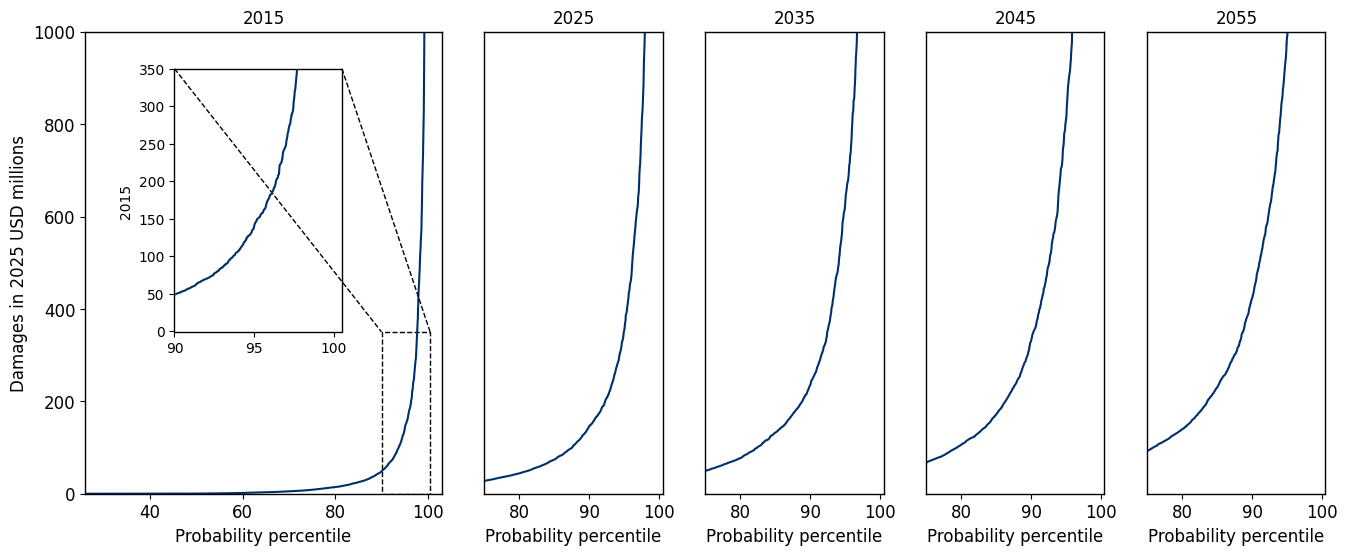

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.gridspec as gridspec

# Assuming curves_df and curve_years are already defined
fig = plt.figure(figsize=(16, 6))

# Create a GridSpec with custom width ratios
gs = gridspec.GridSpec(1, 5, width_ratios=[2, 1, 1, 1, 1, ])

# Create axes using the GridSpec
axes = [fig.add_subplot(gs[0, i]) for i in range(5)]

y_axes_lim = [-0.05 , 1000]
x_axes_lim = [75, 100.5]

# Plot the first subplot with a larger width
sns.lineplot(data=curves_df, x=list(curves_df.index), y=f'{curve_years[0].year}', ax=axes[0])
axes[0].set_title(f'{curve_years[0].year}', fontsize=12)
axes[0].set_ylabel('Damages in 2025 USD millions', fontsize=12)
axes[0].set_xlabel('Probability percentile', fontsize=12)
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].set_xlim([26, x_axes_lim[1] +2.5] )
axes[0].set_ylim( y_axes_lim[0], y_axes_lim[1] )

# Create an inset axes for zooming in on Y > 0
axins = axes[0].inset_axes([0.25, 0.35, 0.47, 0.57],  )

# Set inset background color (optional) and border color
axins.patch.set_facecolor('white')  # Ensures inset is visible
axins.patch.set_edgecolor('black')  # Sets outer edge color
axins.patch.set_linewidth(1)  # Adjusts edge thickness


# Filter the data for Y > 0 and plot on the inset axes
filtered_data = curves_df[curves_df[f'{curve_years[0].year}'] > 0]
sns.lineplot(data=filtered_data, x=list(filtered_data.index), y=f'{curve_years[0].year}', ax=axins)

# Set limits for the inset axes
axins.set_xlim(90, 100.5)  # Adjust as needed
axin_y_max = 350
axins.set_ylim(-1,axin_y_max)  # Adjust as needed

# Mark the inset region on the original plot
mark_inset(axes[0], axins, loc1=2, loc2=1, fc="none",ec="black",  linestyle = '--', )
# mark_inset(axes[0], axins, loc1=3, loc2=3, fc="none",ec="black",  linestyle = '--', )

# Plot the remaining subplots
for year, n in zip(curve_years[1:], range(1, 5)):
    sns.lineplot(data=curves_df, x=list(curves_df.index), y=f'{year.year}', ax=axes[n])
    axes[n].set_title(f'{year.year}', fontsize=12)
    axes[n].set_xlabel('Probability percentile', fontsize=12)
    axes[n].tick_params(axis='both', which='major', labelsize=12)
    axes[n].set_xlim([x_axes_lim[0], x_axes_lim[1]])
    axes[n].set_yticks([])
    axes[n].set_ylim(y_axes_lim[0],  y_axes_lim[1])
    axes[n].set_ylabel('', fontsize=12)

for x in range(0,5):
    for spine in ['bottom', 'top',  'right', 'left']:
        axes[x].spines[spine].set_visible(True)    # Hide the top spine
        axes[x].spines[spine].set_color('black')    # Set left spine color
        axes[x].spines[spine].set_linewidth(1)     # Set left spine width


# plt.tight_layout()
plt.show()
# fig.savefig(here("notebooks/final_paper/data/figures/damage_curves_laos.png"));

In [47]:
# Build the return years table
return_years_table =  build_return_years_curve( curves_df=  curves_df)

# return_years_table.round(1).to_csv(here('data/return_years_table_final_usd_millions.csv'))
return_years_table.round(2)

,2015,2025,2035,2045,2055
return_years,,,,,
100 RY,758.85,2141.26,3068.00,4029.89,4771.33
50 RY,441.53,1026.85,1833.40,2211.75,2452.89
40 RY,309.55,797.93,1353.85,1778.35,1949.41
30 RY,223.97,590.44,978.09,1285.42,1426.48
25 RY,182.21,468.71,796.76,1049.17,1204.30
20 RY,140.73,353.34,628.49,811.74,987.17
10 RY,48.83,146.33,234.77,332.27,422.34
4 RY,8.43,27.78,49.67,67.70,92.43
2 RY,0.29,2.38,6.50,10.60,15.09


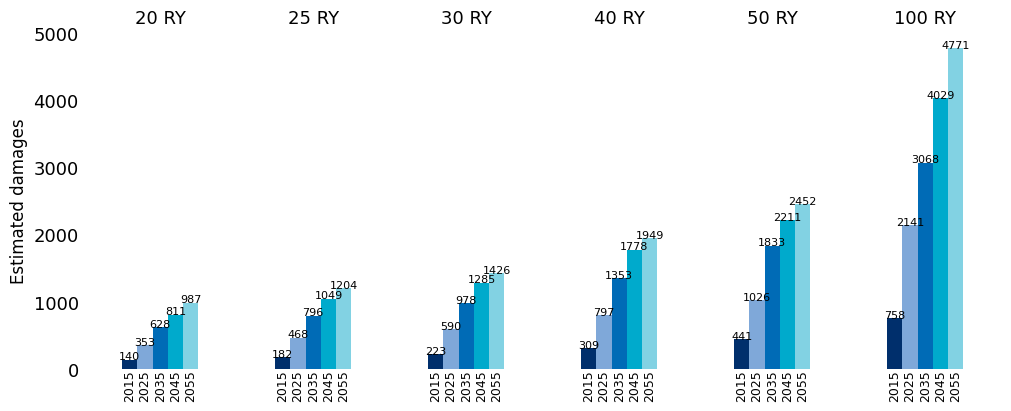

In [48]:
import matplotlib.pyplot as plt
import numpy as np
years_plot = [ str(x.year) for x in curve_years ]

# Create the figure and axis
fig, axes = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# Define the colormap
cmap = plt.get_cmap('crest')

data_plot = return_years_table[years_plot].reset_index().sort_index(ascending = False).tail(6).set_index('return_years')

# Sample more distinct colors from the colormap
# num_colors = data_plot.shape[1]
# colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]

# Plot the data with the modified colormap
bars =data_plot.plot(
    kind='bar',
    ax=axes,
    color=OECD_colors
)


# Add value labels with vertical separation
label_offset = 0.1  # Horizontal offset from the bar
vertical_offset = 0  # Vertical offset between labels

for bar_container in bars.containers:
    for i, bar in enumerate(bar_container):
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        y_pos = height + label_offset  # Adjust label_offset as needed
        axes.text(x_pos, y_pos, f'{int(height)}', fontsize=8, color='black', ha='center')


# Add year labels below each bar
for bar_container, year in zip(bars.containers, years_plot):
    for bar in bar_container:
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        y_pos = -label_offset  # Position below the bar
        axes.text(x_pos, y_pos, f'{year}', fontsize=9, color='black', ha='center', va='top', rotation = 90)


# Set the legend manually
handles, labels = axes.get_legend_handles_labels()
axes.get_legend().remove()

# Set axis labels
axes.set_ylabel('Estimated damages', fontsize=12)
axes.set_xlabel('')
axes.tick_params(axis='both', which='major', labelsize=13,length=0)
axes.set_xticklabels(axes.get_xticklabels(), rotation=0)
axes.xaxis.set_ticks_position('top')
axes.xaxis.set_label_position('top');

# fig.savefig(here("notebooks/final_paper/data/figures/return_year_curves_lao.png"));

In [49]:
# damage_plot( iso = 'LAO', idata= idata_post_combined, 
#             df = plot_damage_df,
#             var_name= 'y_hat_damages', cls='hydro' )


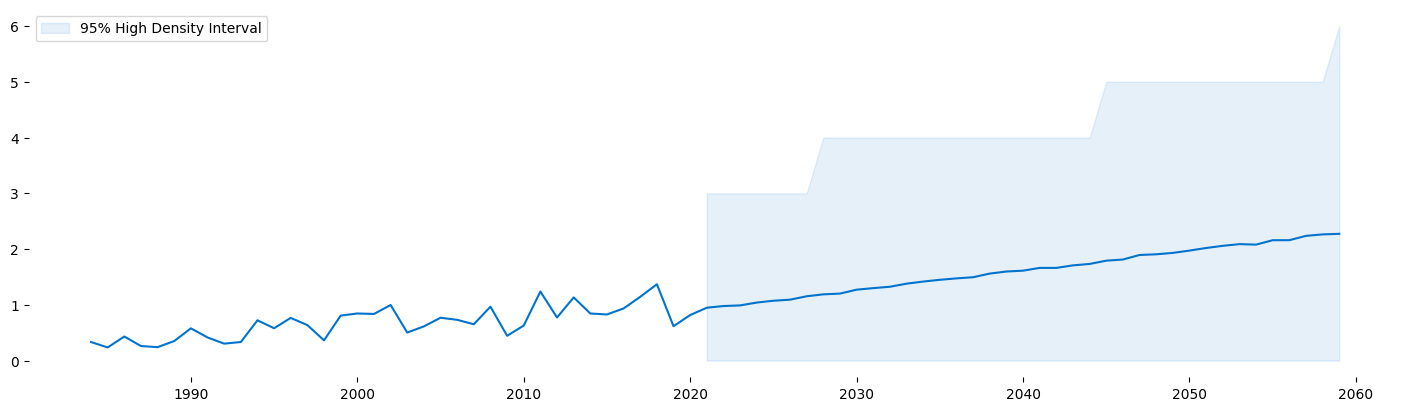

In [50]:
plot_predictions_2(idata_post_combined, 'LAO', 
                 'posterior_predictive',
                 obs_name= None, 
                 var_name= 'y_hat_n_events',
                 data= None,
                disaster = 'hydro')

# Integrating point predictions

In [51]:
# Set random seed
SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [52]:
# Configure pytensir floats
floatX = pytensor.config.floatX
# Load idatas
points_idata = az.from_netcdf(here('notebooks/geo_damage_model/model_closest_synth_15_1000.idata'))

points_idata = points_idata.rename({'country_effect': 'country_effect_points',
                                         'ISO': 'iso_points',
                                         'feature': 'feature_points',
                                         'beta' : 'beta_points'
                         })

#Drop chains to have same chain dim
merged_posteriors_0b = merged_posteriors_0.rename( {'iso': 'iso_curves'})

#Merge posteriors
merged_posterior_1 = xr.merge([points_idata.posterior.drop_dims('obs_idx'),
                              merged_posteriors_0b])

### Points data

In [53]:
grid_cols =  [ 'long', 'lat', 'distance_to_river', 'log_distance_to_river', 'log_distance_to_coastline', 'geometry', 'ISO',
'log_distance_to_river__standardized', 'log_distance_to_coastline__standardized' ]

#Load points data sets
sea_point_grid = pd.read_csv(here("data/sea_point_grid.csv"),index_col=0  )[grid_cols]
laos_point_grid = pd.read_csv(here("data/laos_point_grid.csv"),index_col=0 )[grid_cols]
sea_df = pd.read_csv(here("data/sea.csv"),index_col=0 )
lao_df = pd.read_csv(here("data/lao.csv"),index_col=0 )
sea_df_stand = pd.read_csv(here("data/sea_df_stand.csv"),index_col=0 )
lao_df_stand = pd.read_csv(here("data/lao_df_stand.csv"),index_col=0 )

lao_disasters_geo = gpd.GeoDataFrame(lao_df_stand.query('is_disaster == 1'), 
                                     geometry=gpd.points_from_xy(lao_df_stand.query('is_disaster == 1')["long"],
                                lao_df_stand.query('is_disaster == 1')["lat"]),crs="EPSG:4326")

# Load predictions
predictions_points = pd.read_csv(here("data/climate_forecast.csv")).rename(columns = {"time": "Start_Year"})

predictions_points["year"] =  pd.to_datetime(predictions_points['Start_Year'])

# Load IPCC data
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

In [54]:
# create predictions_ISO

# create predictions_ISO
predictions_points["ISO"] = "LAO"

# Select years of interest
prediction_years = [x for x in curve_years[1:]]
predictions_short = predictions_points.query('year in @prediction_years')

# create grid point number
laos_point_grid = laos_point_grid.reset_index().rename(columns = {"index": "point_number" })

# merge grid and predictions
pred_df = pd.merge(laos_point_grid ,predictions_short, left_on= "ISO", right_on= "ISO", how = "left" )

# Create population density
pred_df["population_density"] = pred_df["Population"] / 236800 # Laos area in squared km hardcoded

# Calculate logs
pred_df["log_population_density"] = np.log(pred_df["population_density"])
pred_df["log_gdp_per_cap"] = np.log(pred_df["gdp_per_cap"])

In [55]:
# Define point features
point_features = ['lat', 'long', 'log_distance_to_river__standardized', 'log_distance_to_coastline__standardized',
       'Population__standardized',
       'co2__standardized', 'precip_deviation__standardized',
       'dev_ocean_temp__standardized', 'log_population_density__standardized',
       'log_gdp_per_cap__standardized',
       # 'log_gdp_per_cap__standardized__squared',
       # 'log_population_density__standardized__squared',
                 ]

beta_point_features = point_features[2:]
distance_features = point_features[0:4]
time_varying_features = point_features[4:]
time_varying_features_base =[x[ :-14] for x in point_features[4:]]

### Standardize data

In [56]:
################## standardize points data ##################
from laos_gggi.transformers import Standardize

# Select cols to stand
cols_to_stand = ['Population', 'dev_ocean_temp',
                 'co2', 'log_population_density', 'log_gdp_per_cap',
       'precip_deviation',]

cols_to_stand_stand = [x + "__standardized" for x in  cols_to_stand]

cols_not_stand = ['ISO' , 'Start_Year', 'year', 'lat', 'long', 'geometry', 'point_number', 'log_distance_to_river__standardized', 'log_distance_to_coastline__standardized']


# Train transformer
transformer_stand_ =  Standardize().fit(sea_df[cols_to_stand])

pred_df_stand = transformer_stand_.transform(pred_df)

# Rename repeated variables
pred_df_stand =  pred_df_stand.rename(columns = {'co2__standardized': 'co2__standardized_p',
                                                'precip_deviation__standardized': 'precip_deviation__standardized_p'})

In [57]:
# # Calculate logs squared
# pred_df_stand["log_gdp_per_cap__standardized__squared"] = pred_df_stand["log_gdp_per_cap__standardized"] **2
# pred_df_stand["log_population_density__standardized__squared"] = pred_df_stand["log_population_density__standardized"] **2

### Center Laos lat-long using SEA data

In [58]:
# Merge with the damages and events join df
df_joint_to_merge =  df_joint_stand[features_events + damage_features_d_stand].loc['LAO']

In [59]:
### Create pred_df_stand_dict for several years
pred_df_stand_dict = {}

pred_df_stand.loc[ : , 'year'] =  pd.to_datetime(pred_df_stand['year'])
# pred_df_stand.loc[ : , 'year'] =pred_df_stand["Start_Year"].astype(int)

for year in pred_df_stand["year"].unique():
    pred_df_stand_dict[year.year] = pred_df_stand[pred_df_stand['year'] == year]
    pred_df_stand_dict[year.year] = pd.merge( pred_df_stand_dict[year.year],
                                          df_joint_to_merge,
                                         on = 'year',
                                          how = 'left')
    pred_df_stand_dict[year.year].loc[:, 'iso']= 'LAO'

### Set coords

In [60]:
# Curve features

year = curve_years[1].year

national_features = list(filter(lambda x: x != 'co2__standardized', damage_features_d_stand))
world_features = ['d_co2__standardized']

# class codes
pred_df_stand_dict[year]['disaster_class'] = 'hydro'
class_idx_joint_2 =  pred_df_stand_dict[year]['disaster_class'].map(class_to_idx.get)

# iso codes
codes_idx_joint_2=   pred_df_stand_dict[year].reset_index()['iso'].map(codes_to_idx.get)


In [61]:
# gp features
gp_features = ["lat", "long"]

# Define point coords
is_disaster_idx_points , is_disaster_points  = pd.factorize(sea_df_stand['is_disaster'])
ISO_idx_points , ISO_points  = pd.factorize(sea_df_stand['ISO']) 
obs_idx_points  = sea_df_stand.index

gp_features = ['lat', 'long']

# Prediction coords
obs_idx = pred_df_stand_dict[year]['point_number']

# Rebuild ISO_idx_sea
ISO_idx, ISO = pd.factorize(sea_df['ISO']) 

ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}
ISO_idx_laos =  pred_df_stand_dict[year].ISO.map(ISO_to_idx.get)

years = pred_df_stand['Start_Year'].unique()

ISO_curves_idx, ISO_curves =  pd.factorize(df_joint_stand.reset_index()['iso'] )
ISO_to_idx_2 = {name: idx for idx, name in enumerate(ISO_curves)}
ISO_curves_idx_laos =  pred_df_stand_dict[year].iso.map(ISO_to_idx_2.get)

#


#Set coords_predictions
coords_flood_walls = {
    # 'is_disaster' : is_disaster,
        'obs_idx': obs_idx,
        'iso_curves':['LAO'], 
        'iso_points': ISO,
        'distance_features': distance_features,
        'time_varying_features' : time_varying_features,
        'point_features': point_features,
        'beta_point_features': beta_point_features,
        'gp_feature':gp_features,
        'features_events': features_events,
        'damage_features': damage_features_d_stand,
        'year':years,
        'national_feature': national_features,
        'world_feature': world_features,
        'disaster': ['climate', 'hydro'],
        'fixed_effect': ['iso', 'year'],
        'year_os' : list(years) ,
    
                     }

In [62]:
# Set coords sea
#Define cooords
is_disaster_idx , is_disaster = pd.factorize(sea_df["is_disaster"])
ISO_idx_sea, ISO_Sea = pd.factorize(sea_df["ISO"]) 
obs_idx_sea = sea_df.index
gp_features = ["lat", "long"]

#Creating idx
xr_idx = xr.Coordinates.from_pandas_multiindex(sea_df.set_index(['ISO', 'Start_Year']).index, 'obs_idx')

#Set coords
coords_sea = {"is_disaster" : is_disaster,
        "obs_idx": obs_idx_sea,
        "ISO": ISO_Sea,
        "feature": beta_point_features,
        "gp_feature":gp_features }


### Set the original model

In [63]:
# Rebuild ISO_idx_sea
ISO_to_idx_point = {name: idx for idx, name in enumerate(ISO_Sea)}
ISO_idx_laos =  pred_df_stand_dict[2025].ISO.map(ISO_to_idx_point.get)

In [64]:
with pm.Model(coords=coords_sea) as model_sea_full:
    #Declare data
    X, Y= add_data(features= beta_point_features ,  target = "is_disaster", df =  sea_df_stand, )
    ISO_idx_pt = pm.Data("ISO_idx_pt", ISO_idx_sea, dims= ["obs_idx"] )
    
    # # #Country effect
    country_effect = pm.Normal("country_effect", mu = 0, sigma =1, dims = ["ISO"])

    # #Betas
    beta_sigma = [0.1] * 8
    beta_points = pm.Normal("beta_points", mu = 0, sigma = beta_sigma, dims = ["feature"])

    # HSGP process
    X_gp = pm.Data("X_gp", sea_df[["lat", "long"]])

    # Prior on the HSGP
    eta = pm.Exponential("eta", scale=2)
    ell_params = pm.find_constrained_prior(
        pm.Lognormal, lower=0.5, upper=10.0, mass=0.95, init_guess={"mu": 1.0, "sigma": 1.0}
    )
    ell = pm.Lognormal("ell", **ell_params, dims=["gp_feature"])
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)

    m0, m1, c = 35, 35, 1.5
    gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)

    phi, sqrt_psd = gp.prior_linearized(X=X_gp)

    basis_coeffs = pm.Normal("basis_coeffs", size=gp.n_basis_vectors)
    HSGP_component = pm.Deterministic("HSGP_component", phi @ (basis_coeffs * sqrt_psd),dims= ["obs_idx"])


    #Model mu
    mu = pm.Deterministic("mu", 
                          country_effect[ISO_idx_pt] + 
                          X@beta_points +
                          HSGP_component , dims= ["obs_idx"] )
    

    # Now define the observed variable separately
    y_hat = pm.Bernoulli('y_hat', logit_p=mu, observed=Y, dims=['obs_idx'])

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\179586340.py:18: FutureWarning: find_constrained_prior is deprecated and will be removed in a future version. Please use maxent function from PreliZ. https://preliz.readthedocs.io/en/latest/api_reference.html#preliz.unidimensional.maxent
  ell_params = pm.find_constrained_prior(


# Compute point predictions

In [65]:
years_numb = [2025, 2035]

In [66]:
idata_plot_point = {}

for year in years_numb:
    temp_model = points_model(model = model_sea_full, df = pred_df_stand_dict[year], 
                 ISO_idx =ISO_idx_laos, 
                              beta_point_features =  beta_point_features,
                             obs_idx = obs_idx)
    
    # if exists(f'idata/idata_plot_point{year}_2.pkl'):
    #     with open(f'idata/idata_plot_point{year}_2.pkl', 'rb') as f:
    #         idata_plot_point[year] = pickle.load(f)
    # else:
    with freeze_dims_and_data(temp_model):
        idata_plot_point[year] = pm.sample_posterior_predictive( points_idata.posterior.drop_dims('obs_idx') , 
                                                                extend_inferencedata=False, 
                                                                var_names=["y_hat",'HSGP_component',
                                                                           "river_effect", "coast_effect",
                                                                          #  "HSGP_component_invlogit",
                                                                          # 'changing_betas_effect',
                                                                          ])
# with open(f'idata/idata_plot_point{year}.pkl', 'wb') as f:
#     pickle.dump(idata_plot_point[year], f)   

Sampling: [country_effect, y_hat]


Output()

Sampling: [country_effect, y_hat]


Output()

In [67]:
# Create the geopandas version of the predictions
from laos_gggi.statistics import get_distance_to_rivers, prediction_to_gpd_df 
gpd_point_event_pred = {}

for year in [2025, 2035]:
    gpd_point_event_pred[year] = prediction_to_gpd_df(prediction_idata = idata_plot_point[year] , 
                         variables = ["y_hat",'HSGP_component',
                                       "river_effect", "coast_effect"
                                     ] , 
                         points = pred_df_stand_dict[year] )

# Combine variables in one df
predictions_geo = {}
for x in [2025, 2035]:
    predictions_geo[x] = pd.concat([gpd_point_event_pred[x]["y_hat"],
               gpd_point_event_pred[x]["HSGP_component"]['HSGP_component'],
               gpd_point_event_pred[x]["river_effect"]['river_effect'],
               gpd_point_event_pred[x]["coast_effect"]['coast_effect']
              ], axis = 1 )

    # Save files
    predictions_geo[x].to_csv(here(f'data/prediction_files/geo_pred_{x}'))

<Axes: >

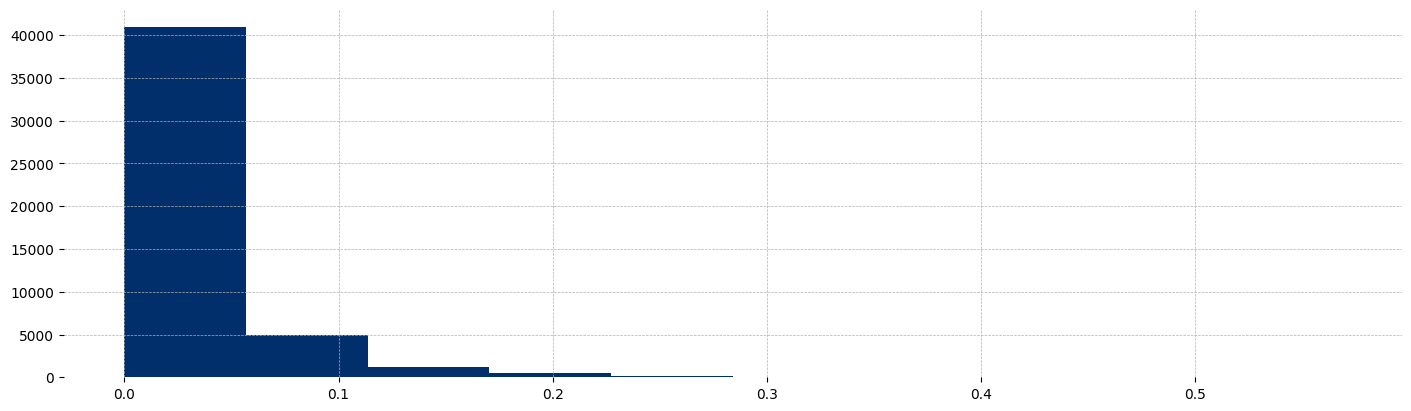

In [68]:
gpd_point_event_pred[2025]["y_hat"]['y_hat'].hist()

<Axes: >

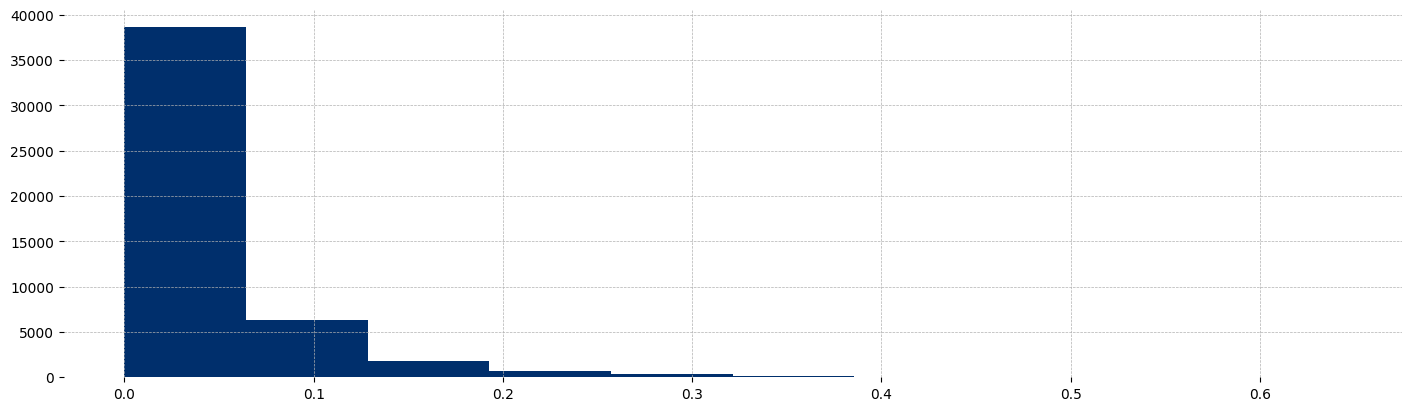

In [69]:
gpd_point_event_pred[2035]["y_hat"]['y_hat'].hist()

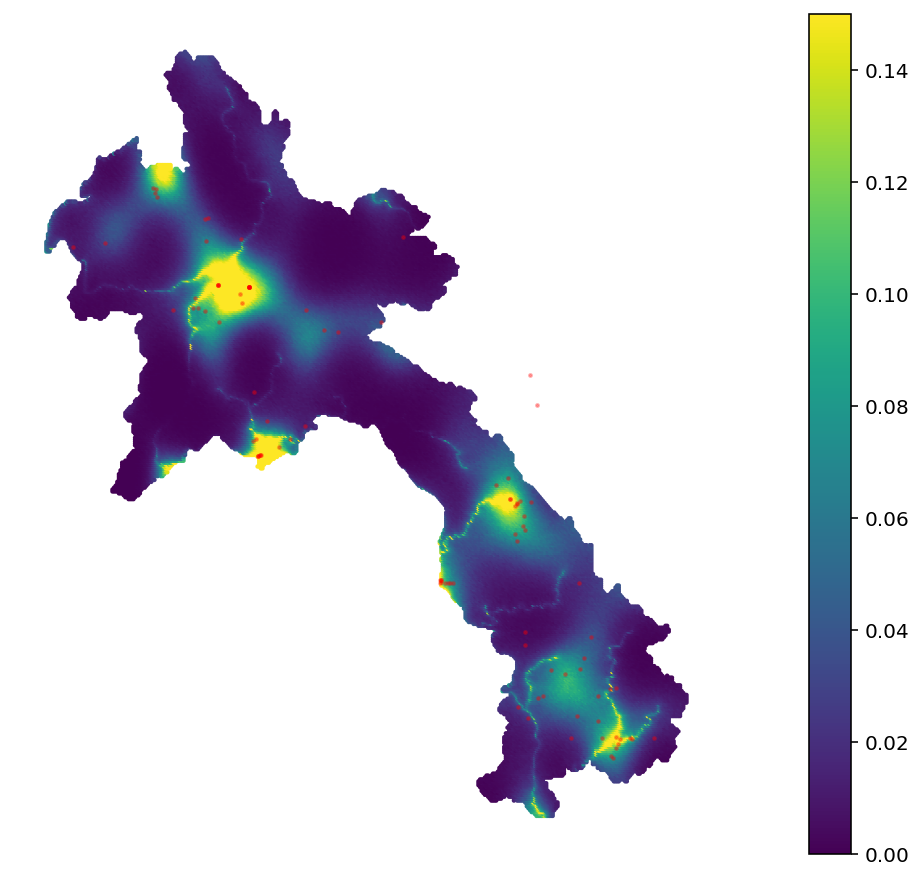

In [70]:
fig, ax = plt.subplots(1,1,figsize=(14, 6), dpi= 144 )
gpd_point_event_pred[2025]["y_hat"].plot("y_hat",legend=True, ax=ax,markersize =1.5, vmax = 0.15 )

lao_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =2, )

ax.set_xticks([])
ax.set_yticks([]);

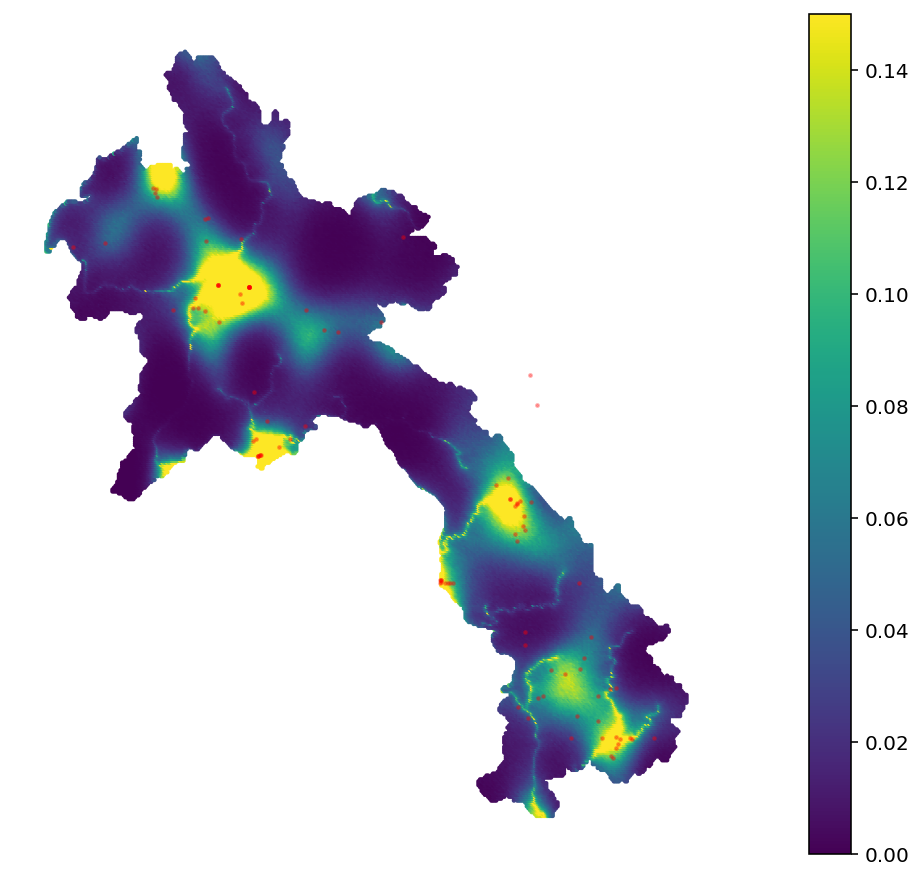

In [71]:
fig, ax = plt.subplots(1,1,figsize=(14, 6), dpi= 144 )
gpd_point_event_pred[2035]["y_hat"].plot("y_hat",legend=True, ax=ax,markersize =1.5, vmax = 0.15 )
lao_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =2, )

ax.set_xticks([])
ax.set_yticks([]);

In [72]:
# merge idatas
curves_pred_idata =  idata_post_combined.posterior_predictive.sel(
                                                                  obs_iso = 'LAO',
                                                                 disaster = 'hydro').rename({'obs_idx':'year' })

final_idatas = {}
for year_ in years_numb:
    final_idatas[year_] = xr.merge([idata_plot_point[year_].posterior_predictive,
                              curves_pred_idata.sel(year = pd.to_datetime( f'{year_}')) ])

    final_idatas[year_] = final_idatas[year_].drop(['obs_iso', 'disaster', 'obs_year'])

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\2277097091.py:11: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  final_idatas[year_] = final_idatas[year_].drop(['obs_iso', 'disaster', 'obs_year'])


In [73]:
simplified_coords = {}

simplified_coords['obs_idx'] = coords_flood_walls['obs_idx']
simplified_coords['obs_disaster_class'] = ['hydro']
simplified_coords['disaster'] = ['hydro']
simplified_coords['obs_iso'] = ['LAO']

In [74]:
with pm.Model(coords=simplified_coords) as point_curves_model_2:
    damages_curves = pm.Flat('damages_curves', dims = ['obs_disaster_class'])
    y_hat = pm.Flat('y_hat', dims = ['obs_idx'])

    point_damage_curve = pm.Deterministic('point_damage_curve', damages_curves * y_hat , dims = ['obs_idx'])

In [75]:
point_damage_curves = {}
for year in years_numb:
    with freeze_dims_and_data(point_curves_model_2 ):
        point_damage_curves[year] = pm.sample_posterior_predictive( final_idatas[year]  ,  extend_inferencedata = True, 
                                                                        var_names=["point_damage_curve",])

        final_idatas[year] = xr.merge([point_damage_curves[year].posterior_predictive,
                                           final_idatas[year]])


Sampling: []


Output()

Sampling: []


Output()

# City examples

In [76]:
# We now identify the cities

city_points = {'Vientiane': {'lat': 17.9757, 'long': 102.6331},
                            'Luang Prabang': {'lat': 19.8860, 'long': 102.1350},
                            'Savannakhet': {'lat': 16.5575, 'long': 104.7528},
                            'Pakse': {'lat': 15.1202, 'long': 105.7987},
                            # 'Thakhek': {'lat': 17.4106, 'long': 104.8304},
                            'Attapeu': {'lat': 14.8086, 'long':106.8230 },
                        }

# Obtain the city points in the predictions
dist_square = {}
best_loc_index = {} 
best_loc = {}
cities = city_points.keys()

for city in cities:
    dist_square[city] = ((pred_df_stand_dict[2025]["lat"] -city_points[city]["lat"])**2 + (pred_df_stand_dict[2025]["long"] -city_points[city]["long"])**2)
    best_loc_index[city] =  dist_square[city].sort_values().head(1).index.values[0]
    best_loc[city] = pred_df_stand_dict[2025].loc[best_loc_index[city]][["lat", "long", "point_number"]]


# Save locations 
# pd.DataFrame(best_loc).T.to_csv(here('data/cites_loc.csv'))

In [77]:
# We select the city projections idata
city_predictions = {}

for city in cities:
    city_predictions[city] = {}
    for year in years_numb:
        city_predictions[city][year] =  final_idatas[year].sel(obs_idx = best_loc[city]["point_number"] )

In [78]:
# We now build the return-year curves
computed_ry_damage = {}
curves_df_cities = {}  
curves_df_cities['no_fw'] = {}
for city in cities:
    computed_ry_damage[city] = {}
    curves_df_cities['no_fw'][city] = pd.DataFrame( )
    
    for year in years_numb:
        
        damages = city_predictions[city][year]['point_damage_curve'].values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys = np.linspace(1, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([1, 2, 2.5, (10/3), 4, 5,  10, 25, 50, 75]) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year
        computed_ry_damage[city][year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df_cities['no_fw'][city] = pd.concat([curves_df_cities['no_fw'][city],computed_ry_damage[city][year_].T], axis=1)
        
    curves_df_cities['no_fw'][city]= curves_df_cities['no_fw'][city].reset_index()
    curves_df_cities['no_fw'][city] =  curves_df_cities['no_fw'][city].assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df_cities['no_fw'][city] = curves_df_cities['no_fw'][city].sort_index(ascending= True)

In [79]:
city_predictions['Luang Prabang'][2025]['y_hat'].mean()

<xarray.DataArray 'y_hat' ()> Size: 8B
array(0.321875)
Coordinates:
    obs_idx  int32 4B 32680

In [80]:
city_predictions['Luang Prabang'][2025]['y_hat'].mean()

<xarray.DataArray 'y_hat' ()> Size: 8B
array(0.321875)
Coordinates:
    obs_idx  int32 4B 32680

In [81]:
city_predictions['Attapeu'][2025]['y_hat'].mean()

<xarray.DataArray 'y_hat' ()> Size: 8B
array(0.280875)
Coordinates:
    obs_idx  int32 4B 2590

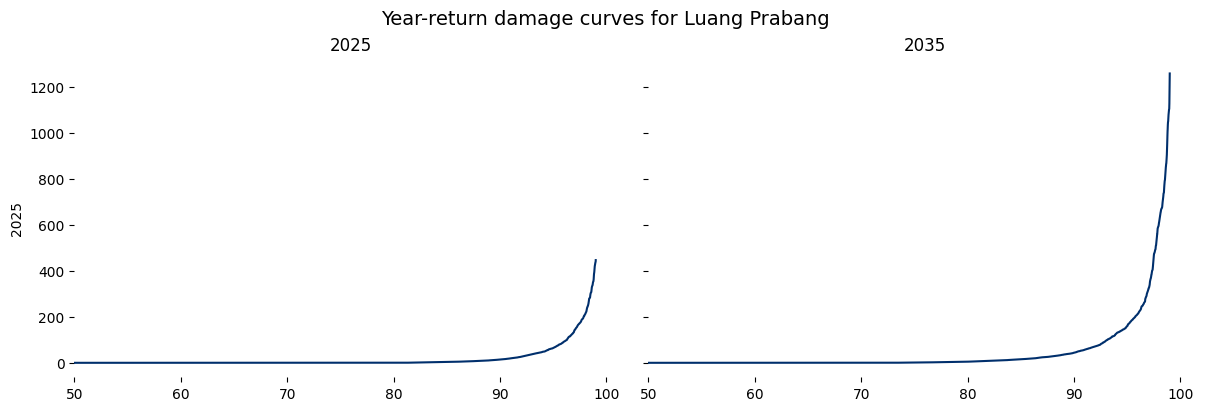

In [82]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharey= True)
axes = axes.flatten()

city = 'Luang Prabang'

for year, n in zip([2025, 2035] , range(0,2)):
    sns.lineplot( data = curves_df_cities['no_fw'][city] , x = list(curves_df_cities['no_fw'][city].index), y = f'{year}', ax= axes[n])
    # axes[n].invert_xaxis()
    axes[n].set_title(f'{year}')
    axes[n].set_xlim(50, 102)

plt.suptitle(f'Year-return damage curves for {city}', size = 14);

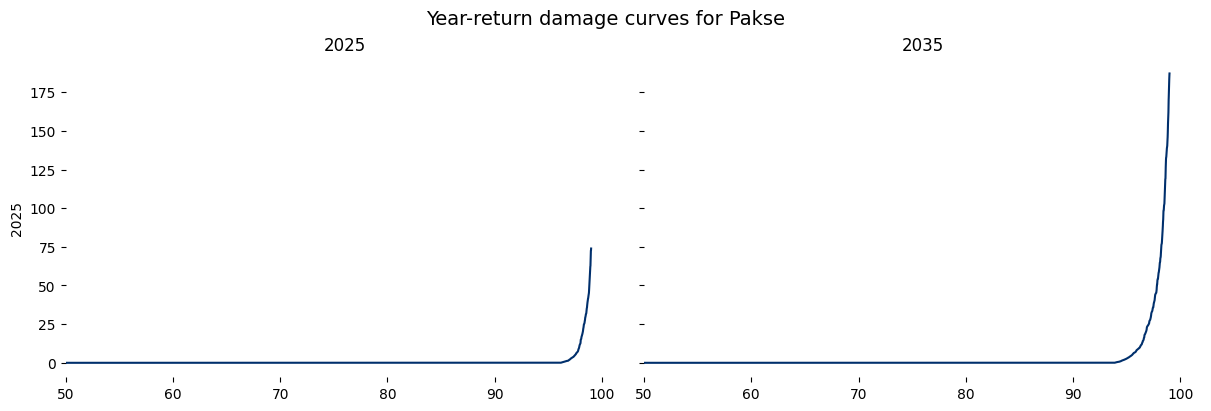

In [83]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharey= True)
axes = axes.flatten()

city = 'Pakse'

for year, n in zip([2025, 2035] , range(0,2)):
    sns.lineplot( data = curves_df_cities['no_fw'][city] , x = list(curves_df_cities['no_fw'][city].index), y = f'{year}', ax= axes[n])
    # axes[n].invert_xaxis()
    axes[n].set_title(f'{year}')
    axes[n].set_xlim(50, 102)

plt.suptitle(f'Year-return damage curves for {city}', size = 14);

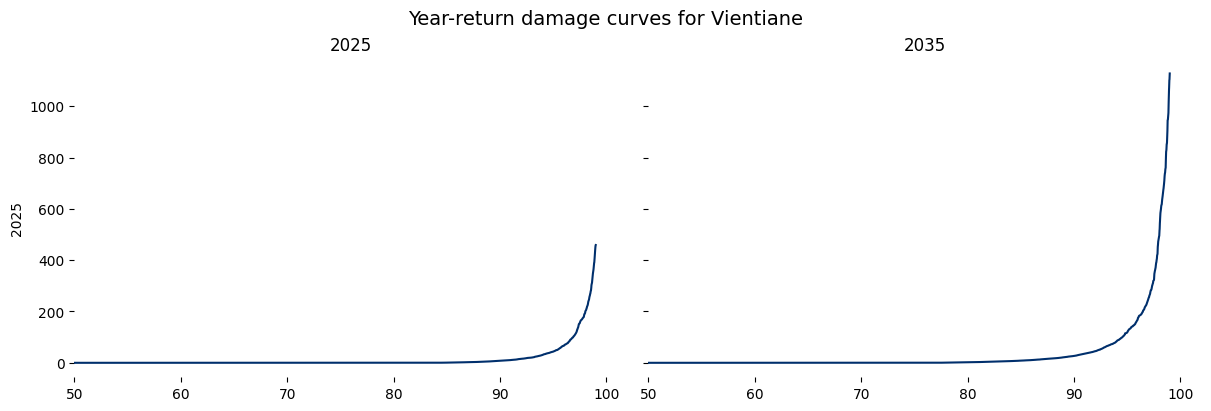

In [84]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharey= True)
axes = axes.flatten()

city = 'Vientiane'

for year, n in zip([2025, 2035] , range(0,2)):
    sns.lineplot( data = curves_df_cities['no_fw'][city] , x = list(curves_df_cities['no_fw'][city].index), y = f'{year}', ax= axes[n])
    # axes[n].invert_xaxis()
    axes[n].set_title(f'{year}')
    axes[n].set_xlim(50, 102)

plt.suptitle(f'Year-return damage curves for {city}', size = 14);

# Predictions with IPCC data

In [85]:
# Load ipcc predictions
ipcc_predictions =  process_ipcc_scenarios().rename(columns = {'year': 'year_'})

# Create the year_ variable for  predictions
predictions['year_'] = predictions['year'].dt.year

# Merge with predictions 
pred_comparison_df = pd.merge(predictions, ipcc_predictions , on = 'year_', how = "left"  )

In [86]:
# we define the CO2 scenarios to use
scenarios_to_use = ['SSP1-19', 'SSP5-85',]
scenarios_to_use_stand = ["co2_" +  x + "__standardized" for x in scenarios_to_use]
scenarios_to_use_stand_d = ["d_co2_" + x + "__standardized" for x in scenarios_to_use]

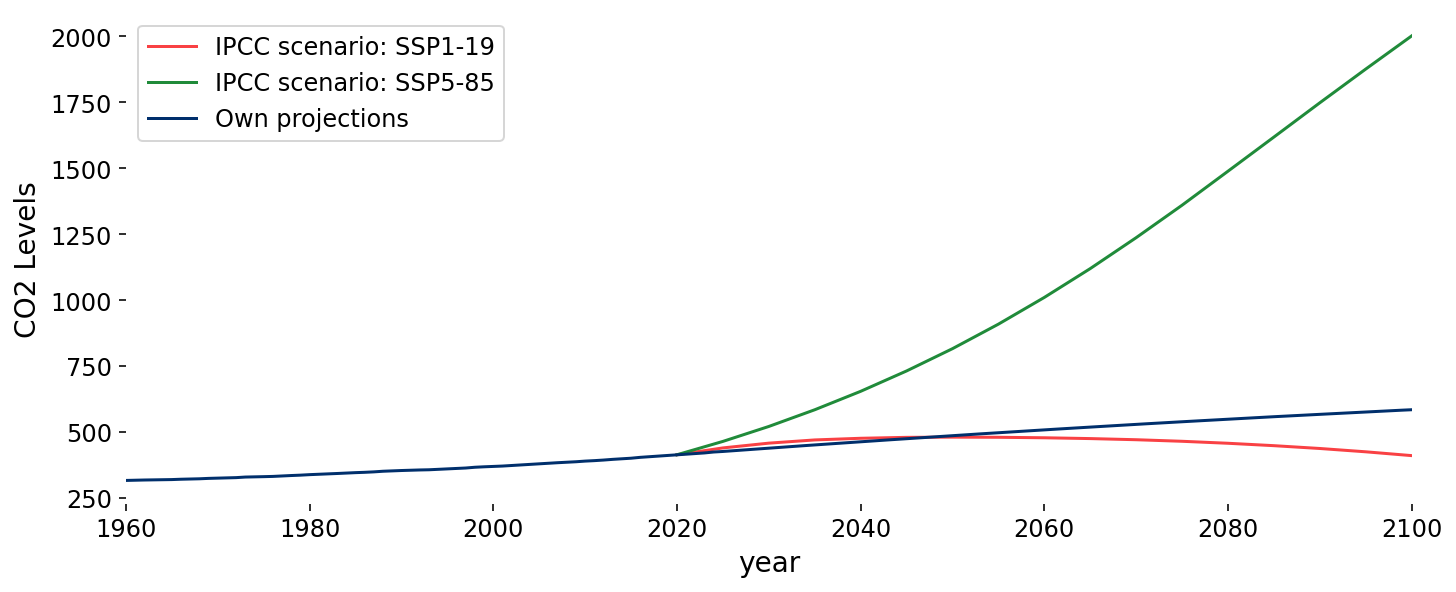

In [87]:
cols_to_plot = scenarios_to_use

colors_ippc = ['#f94144',   '#208b3a',]

fig, axes = plt.subplots(1, 1, figsize=(10, 4), sharex=True, dpi=144)

for series, color in zip(cols_to_plot, colors_ippc):
    sns.lineplot(x= pred_comparison_df["year_"], y= pred_comparison_df[series], ax=axes,
                 label="IPCC scenario: " + series, c =color )

sns.lineplot(x = pred_comparison_df["year_"], y= pred_comparison_df["co2"], ax=axes,
             label="Own projections", )

axes.set_xlim(1960, 2100)

# Increase text size
# plt.title("IPCC Projections and Own Projections for CO2", fontsize=18)
axes.set_xlabel("year", fontsize=14)
axes.set_ylabel("CO2 Levels", fontsize=14)
axes.tick_params(axis='both', labelsize=12)
axes.legend(fontsize=12)


# fig.savefig(here("notebooks/final_paper/data/figures/ipcc_co2_pred.png"));
plt.show()

In [88]:
# Now we standardize the CO2 scenarios for events and damages
for scenario in scenarios_to_use:
    df_damage.loc[ : , scenario] = df_damage["co2"].copy()
    sea_df_stand.loc[ : , scenario] = sea_df_stand["co2"].copy()

# We train the transformers
transform_co2_d = Standardize().fit( df_damage[scenarios_to_use] )
transform_co2 = Standardize().fit(sea_df_stand[scenarios_to_use] )

# Drop the fake scenarios used to transform
df_damage= df_damage.drop(columns = scenarios_to_use)
sea_df_stand = sea_df_stand.drop(columns = scenarios_to_use)


# We transform the data
transformed_co2_d = transform_co2_d.transform(pred_comparison_df[scenarios_to_use] )
transformed_co2_d.columns = ['SSP1-19', 'SSP5-85'] + scenarios_to_use_stand_d
pred_comparison_df = pd.merge(pred_comparison_df,transformed_co2_d[scenarios_to_use_stand_d] , left_index=True, right_index=True, how = "left" )
transformed_co2 = transform_co2.transform( pred_comparison_df[scenarios_to_use] )
transformed_co2.columns =  ['SSP1-19', 'SSP5-85'] + scenarios_to_use_stand
pred_comparison_df = pd.merge(pred_comparison_df, transformed_co2[scenarios_to_use_stand] , left_index=True, right_index=True, how = "left" )

In [89]:
# df_joint_stand = base_df_joint_stand.copy()

In [90]:
# Now we introduce the data into the predictions data frames
keys = list(pred_df_stand_dict.keys())

stand_ipcc_list = scenarios_to_use_stand + scenarios_to_use_stand_d

for date in keys:
    for projection in stand_ipcc_list:
        value = pred_comparison_df.query('year_ == @date')[projection].values[0]
        pred_df_stand_dict[date].loc[ : , projection] = value

# Create the year_ col
df_joint_stand =(  df_joint_stand.reset_index().assign(year_ = lambda x: x['year'].dt.year )
                 .set_index(['iso', 'year']).sort_index())



# merge with the projections
df_joint_stand = pd.merge(df_joint_stand.reset_index(),
                        pred_comparison_df[[ 'year_', 'SSP1-19', 'SSP5-85', 'd_co2_SSP5-85__standardized', 'd_co2_SSP1-19__standardized']],
                       on = 'year_',
                       how = "left").set_index(['iso', 'year']).sort_index()

for projection in [ 'd_co2_SSP5-85__standardized', 'd_co2_SSP1-19__standardized']:
   df_joint_stand[projection] = np.where(df_joint_stand['year_'] <= 2020, df_joint_stand['co2__standardized'], df_joint_stand[projection])

for projection in [ 'SSP1-19', 'SSP5-85']:
   df_joint_stand[projection] = np.where(df_joint_stand['year_'] <= 2020, df_joint_stand['co2'], df_joint_stand[projection])



In [91]:
# Now we adjust the features for the model
# Events
features_events_SSP1 = ['ln_population_density',
 'ln_gdp_pc',
 'square_ln_gdp_pc',
 'precip_deviation',
 'SSP1-19',
 'population']

features_events_SSP5 = ['ln_population_density',
 'ln_gdp_pc',
 'square_ln_gdp_pc',
 'precip_deviation',
 'SSP5-85',
 'population']

e_features_ipcc = [ features_events_SSP1, features_events_SSP5 ]

# Damage 
damage_features_d_stand_SSP5 = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'ln_gdp_pc__standardized_squared',
 'precip_deviation__standardized',
 'd_co2_SSP5-85__standardized',
 'population__standardized']

damage_features_d_stand_SSP1 = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'ln_gdp_pc__standardized_squared',
 'precip_deviation__standardized',
 'd_co2_SSP1-19__standardized',
 'population__standardized']

d_features_ipcc = [ damage_features_d_stand_SSP1, damage_features_d_stand_SSP5 ]

# Points
point_features_SSP5 = ['log_distance_to_river__standardized',
 'log_distance_to_coastline__standardized',
 'Population__standardized',
 'co2_SSP5-85__standardized',
 'precip_deviation__standardized',
 'dev_ocean_temp__standardized',
 'log_population_density__standardized',
 'log_gdp_per_cap__standardized',
                    ]

point_features_SSP1 = ['log_distance_to_river__standardized',
 'log_distance_to_coastline__standardized',
 'Population__standardized',
 'co2_SSP1-19__standardized',
 'precip_deviation__standardized',
 'dev_ocean_temp__standardized',
 'log_population_density__standardized',
 'log_gdp_per_cap__standardized',
                    ]

p_features = [ point_features_SSP1, point_features_SSP5 ]


In [92]:
point_damage_curves = {}
for year in years_numb:
    with freeze_dims_and_data(point_curves_model_2 ):
        point_damage_curves[year] = pm.sample_posterior_predictive( final_idatas[year]  ,  extend_inferencedata = True, 
                                                                        var_names=["point_damage_curve",])

        final_idatas[year] = xr.merge([point_damage_curves[year].posterior_predictive,
                                       final_idatas[year]])

            # with open(f'idata/final_idatas{year}.pkl', 'wb') as f:
            #     pickle.dump(final_idatas[year], f)      

Sampling: []


Output()

Sampling: []


Output()

In [93]:
# Run the curves model
combined_model_ippc = {}
points_model_ippc = {}

combined_model_ippc_plot = {}
points_model_ippc_plot = {}

model_point_damage_curves = {}

ipcc_point_projections = {}

for scenario, e_feature, d_feature, p_feature   in zip(scenarios_to_use, e_features_ipcc, d_features_ipcc, p_features):
    ipcc_point_projections[scenario] = {}

    combined_model_ippc[scenario]  = curves_model(coords = coords_combined , df = df_joint_stand ,
                                                        codes_idx_joint = codes_idx_joint,
                                                        features_events = e_feature,
                                                        damage_features_d_stand= d_feature,
                                                        class_idx_joint = class_idx_joint ) 

    with freeze_dims_and_data(combined_model_ippc[scenario] ):
        
        combined_model_ippc_plot[scenario] = pm.sample_posterior_predictive(merged_posteriors_0 , extend_inferencedata=False, 
                                                          compile_kwargs={'mode':'JAX'},
                                                    var_names=[ 
                                                        'damages_curves', 
                                                        'y_hat_damages',
                                                        'y_hat_n_events']
                                                           )

        combined_model_ippc_plot[scenario] = combined_model_ippc_plot[scenario].assign_coords(combined_xr_idx)


        # Drop the additioal chains and select the dimension
    combined_model_ippc_plot[scenario] =  combined_model_ippc_plot[scenario].posterior_predictive.sel(
                                                                  obs_iso = 'LAO',
                                                                 disaster = 'hydro').rename({'obs_idx':'year' })
        
    
    # Points model
    points_model_ippc[scenario] = {}
    points_model_ippc_plot[scenario] = {}
    model_point_damage_curves[scenario] = {}
    for year in years_numb:     
        points_model_ippc[scenario][year] = points_model(model = model_sea_full,
                                                         beta_point_features = p_feature,
                                                         ISO_idx =  ISO_idx_laos,
                                                         obs_idx = obs_idx,
                                                        df = pred_df_stand_dict[year] , 
                                       )
        with freeze_dims_and_data( points_model_ippc[scenario][year] ):
            points_model_ippc_plot[scenario][year] = pm.sample_posterior_predictive( points_idata.posterior.drop_dims('obs_idx') , 
                                                                        extend_inferencedata=False, 
                                                                        var_names=["y_hat"])

        # Merge idatas 
        ipcc_point_projections[scenario][year] = xr.merge( [points_model_ippc_plot[scenario][year].posterior_predictive ,
                          combined_model_ippc_plot[scenario].sel(year = pd.to_datetime( f'{year}')) ])
    
        ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])

        # with open(f'idata/points_model_ippc{scenario}_{year}.pkl', 'wb') as f:
        #     pickle.dump(ipcc_point_projections[scenario][year], f)   

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\link\jax\linker.py:27: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x1FE6D53EA40>), RNG(<Generator(PCG64) at 0x1FE6D534040>), RNG(<Generator(PCG64) at 0x1FDCA8F02E0>), RNG(<Generator(PCG64) at 0x1FE6D53E880>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: sigma > 0) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
Sampling: [y_hat_damages, y_hat_n_events]


Output()

Sampling: [country_effect, y_hat]


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\1026239965.py:60: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: [country_effect, y_hat]


...

Sampling: [country_effect, y_hat]


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\1026239965.py:60: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: [country_effect, y_hat]


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\1026239965.py:60: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])


In [94]:
computed_ry_damage_scen_scen = {}
curves_df_scen = {}  
retunr_year_tables = {}

for scenario in scenarios_to_use:
    computed_ry_damage_scen_scen[scenario] = {}
    curves_df_scen[scenario] = pd.DataFrame( )
    
    for year in years_numb:
        
        damages = ipcc_point_projections[scenario][year]['damages_curves'].values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys = np.linspace(1, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([1, 2, 2.5, (10/3), 4, 5,  10, 25, 50, 75]) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year
        computed_ry_damage_scen_scen[scenario][year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df_scen[scenario] = pd.concat([curves_df_scen[scenario],computed_ry_damage_scen_scen[scenario][year_].T], axis=1)
        
    curves_df_scen[scenario]= curves_df_scen[scenario].reset_index()
    curves_df_scen[scenario] =  curves_df_scen[scenario].assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df_scen[scenario] = curves_df_scen[scenario].sort_index(ascending= True)
    retunr_year_tables[scenario] = build_return_years_curve( curves_df=  curves_df_scen[scenario])


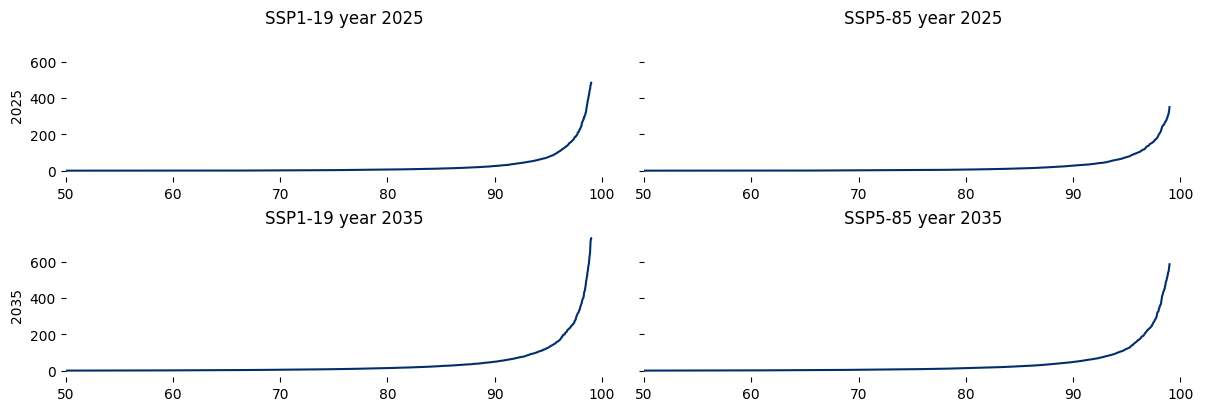

In [95]:
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize = (12, 4), sharey= True)

for scenario, n in zip(scenarios_to_use, range(0,2)):

    for year, m in zip(years_numb , range(0,2)):
        sns.lineplot( data = curves_df_scen[scenario] ,
                     x = list(curves_df_scen[scenario].index), y = f'{year}', ax= axes[m,n])
        # axes[n].invert_xaxis()
        axes[m,n].set_title(f'{scenario} year {year}')
        axes[m,n].set_xlim(50, 102)
    
    # plt.suptitle(f'Year-return damage curves for {city}', size = 14);

In [96]:
table_SSP1 = retunr_year_tables['SSP1-19']

table_SSP5= retunr_year_tables['SSP5-85']

table_SSP5_r = table_SSP5.rename(columns = {'2025': '2025_SSP5-85',
                           '2035': '2035_SSP5-85',
                           })
table_SSP1_r =table_SSP1.rename(columns = {'2025': '2025_SSP1-19',
                           '2035': '2035_SSP1-19',
                          })

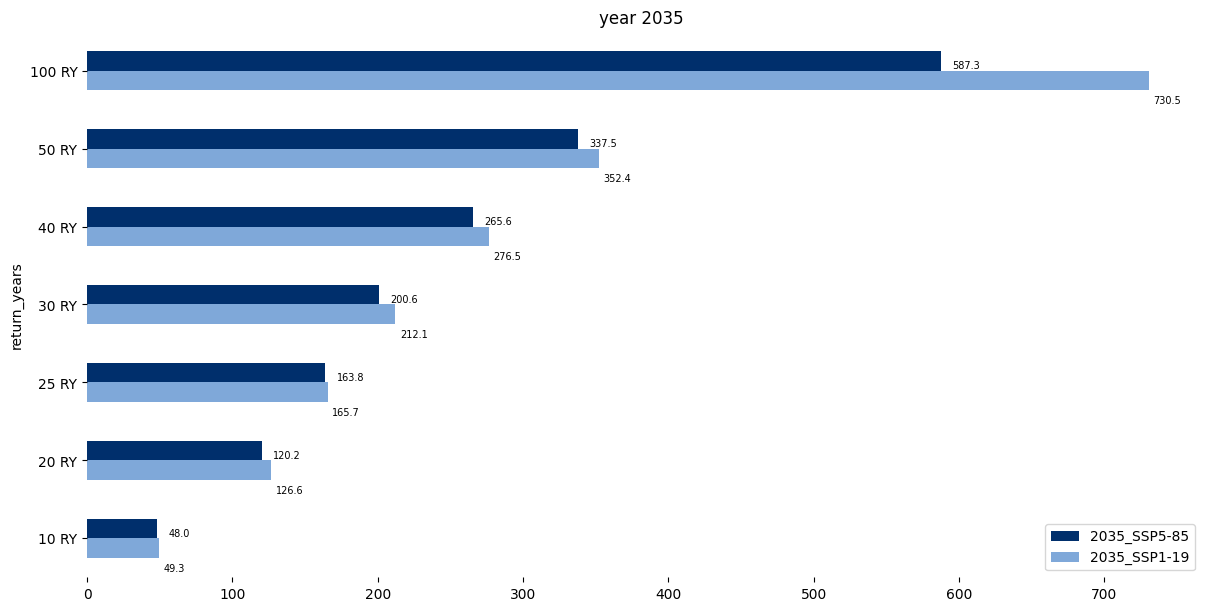

In [97]:
fig, axes = plt.subplots(1,1, figsize = (12,6), sharex= True )
label_offset = 1
vertical_offset = 0.1


for a,b, n, year in zip( [ '2035_SSP5-85' ] ,  [ '2035_SSP1-19'], range(0,2), [ '2035']):
    bars = table_SSP5_r[[a]].join(table_SSP1_r[b] ).head(7).plot(kind = 'barh', ax = axes )
    
    axes.invert_yaxis()
    axes.set_title(f'year {year} ')

    for bar_container, t, p in zip(bars.containers, [7, 2], [0, 0.2 ]):
        for i, bar in enumerate(bar_container):
            width = bar.get_width()
            y_pos = bar.get_y() + bar.get_height() / 2 + ( vertical_offset)
            axes.text(width + (label_offset) + t , y_pos + p,
                  f'{(width.round(1))}', fontsize= 7, color='black')

# fig.savefig(here("notebooks/final_paper/data/figures/ipcc_damage_curves.png"));

#### Plotting the different scenario heatmaps

In [98]:
points_model_ippc_plot_geo= {}
for scenario in ['SSP1-19', 'SSP5-85']:
    points_model_ippc_plot_geo[scenario] = {}
    
    for year in [2025, 2035]:
        points_model_ippc_plot_geo[scenario][year] = prediction_to_gpd_df(prediction_idata = points_model_ippc_plot[scenario][year] , 
                             variables = ["y_hat"] , 
                             points = pred_df_stand_dict[year] )

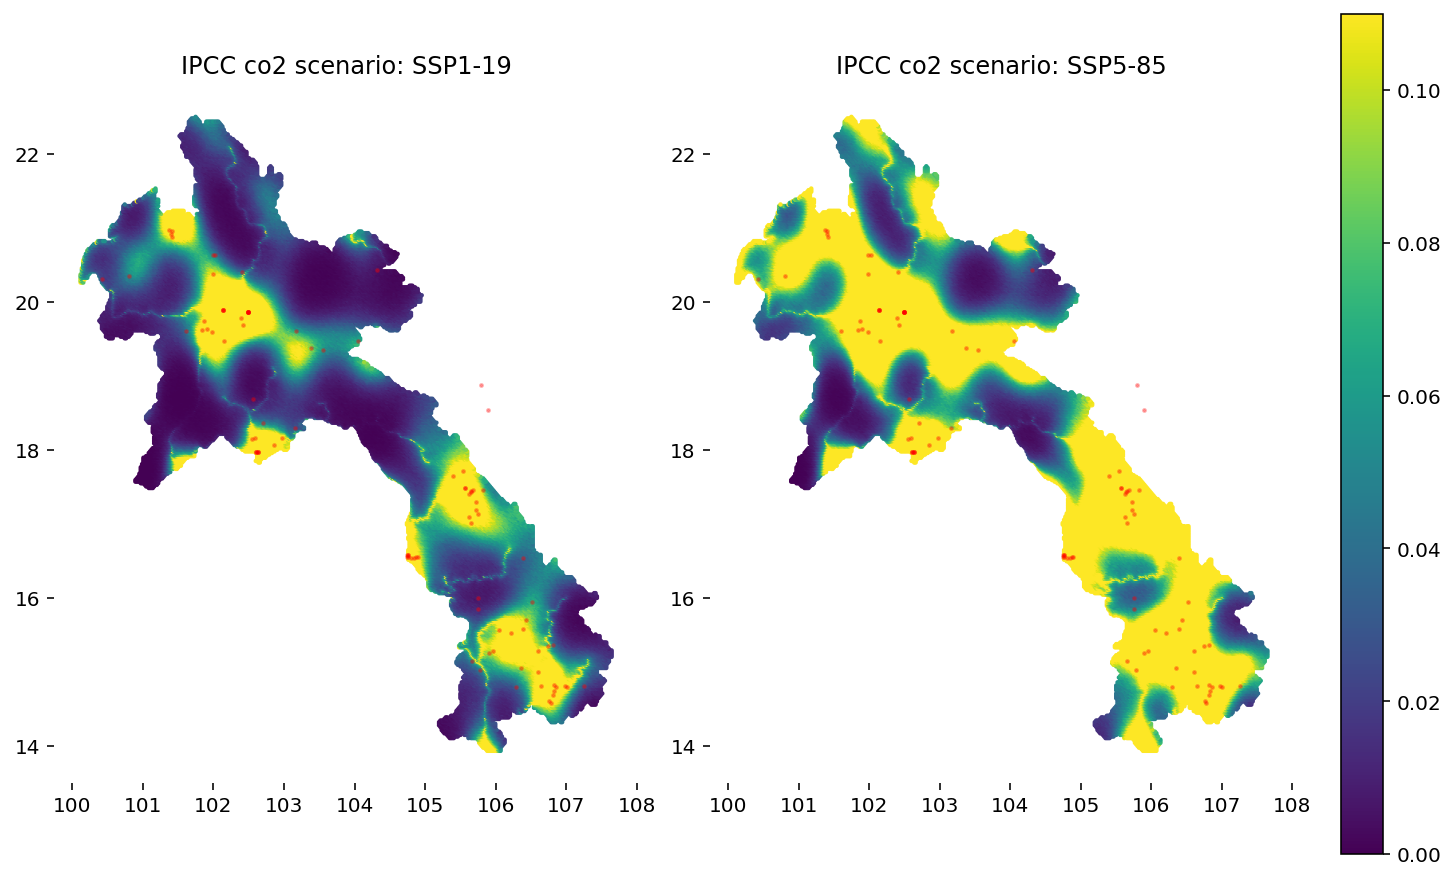

In [99]:
# Different scenarios
fig, axes = plt.subplots(1,2,figsize=(10, 6), dpi= 144 )

# # Current scenario
# gpd_point_event_pred[2035]["y_hat"].plot("y_hat",legend=False, ax = axes[1] ,markersize =1.5, vmax = 0.1 )
# lao_disasters_geo.plot(ax = axes[1], alpha = 0.3, c = "r", markersize =2, )

legend_list = [False, True]

for scenario, n in zip(['SSP1-19', 'SSP5-85'], [0,1]):
    points_model_ippc_plot_geo[scenario][2035]['y_hat'].plot("y_hat",legend=legend_list[n], ax = axes[n] ,markersize =1.5, vmax = 0.11 )
    lao_disasters_geo.plot(ax = axes[n], alpha = 0.3, c = "r", markersize =2, )
    axes[n].set_title('IPCC co2 scenario: '+ scenario)

# fig.savefig(here("notebooks/final_paper/data/figures/ipcc_scen_maps.png"));

# Modeling the construction of flood walls

For this exercise, we select two points:

Vientiane: The capital is located along the Mekong River and has experienced several major floods in the past. One of the most severe occurred in 2008.
Pakse: Situated on the Mekong River in southern Laos. Pakse has experienced seasonal flooding, particularly during heavy monsoons, with significant events recorded in 2013 and 2019.

In [100]:
# define loop variables
wall_cities = ["Vientiane", "Savannakhet", "Pakse"]
river_variables = ["log_distance_to_river__standardized", "log_distance_to_river__standardized__squared"]
wall_variables = [x + "_wall" for x in river_variables]
max_river_0 = pred_df_stand_dict[2025]["log_distance_to_river__standardized"].max()
# max_river_1 = pred_df_stand_dict[2030]["log_distance_to_river__standardized__squared"].min()

index_val = {}
city_pred_data = {}

wall_df = {}

# create the new distance to river variables (this is the core of the flood wall simulation)
for city in wall_cities:
    index_val[city] = {}
    city_pred_data[city] = {}
    for year in years_numb:
        wall_df[year] = pred_df_stand_dict[year].copy()
        # log_distance_to_river__standardized
        wall_df[year].loc[ : ,  wall_variables[0] ] = pred_df_stand_dict[year].loc[ : , "log_distance_to_river__standardized" ]
        # wall_df[year].loc[ : ,  wall_variables[1] ] = pred_df_stand_dict[year].loc[ : , "log_distance_to_river__standardized__squared" ]
        
        point_num = best_loc[city].loc["point_number"]
        index_val[city][year] = pred_df_stand_dict[year].query('point_number == @point_num').index.values[0]
        
        # Re-write the values
        wall_df[year].loc[ : , wall_variables[0] ] = max_river_0

        # # log_distance_to_river__standardized__squared
        # wall_df[year].loc[ : , wall_variables[1] ] = max_river_1

        # Store the city values
        city_pred_data[city][year] =  wall_df[year].loc[index_val[city][year], : ]
        
    city_pred_data[city] = pd.DataFrame(city_pred_data[city]).T

In [101]:
# Define the wall features
event_features_wall = beta_point_features.copy()
event_features_wall[0] = "log_distance_to_river__standardized_wall"
# event_features_wall[-2] = "log_distance_to_river__standardized__squared_wall"

In [102]:
# Ruen the flood wall cases
flood_wall_model = {}
flood_wall_point_pred = {}
flood_wall_point_pred_merged = {}
final_flood_wall_idatas = {}
for year in years_numb:
    # Create the model
    flood_wall_model[year] =  points_model(model = model_sea_full, 
                                            beta_point_features = event_features_wall,
                                            df = wall_df[year] , 
                                            ISO_idx =  ISO_idx_laos,
                                             obs_idx = obs_idx,
                                       )
    # Sample the points flood_wall model
    if exists(f'idata/flood_wall_point_pred{year}_2.pkl'):
        with open(f'idata/flood_wall_point_pred{year}_2.pkl', 'rb') as f:
            flood_wall_point_pred[year] = pickle.load(f)

    else:
        with freeze_dims_and_data( flood_wall_model[year] ):
            flood_wall_point_pred[year] = pm.sample_posterior_predictive( points_idata.posterior.drop_dims('obs_idx') , 
                                                                        extend_inferencedata=False, 
                                                                        var_names=["y_hat"])
        with open(f'idata/flood_wall_point_pred{year}.pkl_2', 'wb') as f:
            pickle.dump(flood_wall_point_pred[year], f)  
        # Merge idatas 
        final_flood_wall_idatas[year] = xr.merge( [ flood_wall_point_pred[year].posterior_predictive,
                                                         curves_pred_idata.sel(year = pd.to_datetime( f'{year_}')) ])
        
        final_flood_wall_idatas[year] = final_flood_wall_idatas[year].drop(['obs_iso', 'disaster', 'obs_year'])

Sampling: [country_effect, y_hat]


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\1277411750.py:30: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  final_flood_wall_idatas[year] = final_flood_wall_idatas[year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: [country_effect, y_hat]


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\1277411750.py:30: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  final_flood_wall_idatas[year] = final_flood_wall_idatas[year].drop(['obs_iso', 'disaster', 'obs_year'])


In [103]:
# Sample the point damage curve predictions
final_flood_wall_idatas_plot = {}
for year in years_numb:
    if exists(f'idata/final_flood_wall_idatas_plot{year}_2.pkl'):
        with open(f'idata/final_flood_wall_idatas_plot{year}_2.pkl', 'rb') as f:
            final_flood_wall_idatas_plot[year] = pickle.load(f)
    else:
        with freeze_dims_and_data(point_curves_model_2 ):
            final_flood_wall_idatas_plot[year] = pm.sample_posterior_predictive( final_flood_wall_idatas[year], extend_inferencedata = True, 
                                                                        var_names=["point_damage_curve",])
        with open(f'idata/final_flood_wall_idatas_plot{year}_2.pkl', 'wb') as f:
            pickle.dump(final_flood_wall_idatas_plot[year], f)  

In [104]:
# We select the city projections idata
city_predictions_flood_wall = {}

for city in cities:
    city_predictions_flood_wall[city] = {}
    for year in years_numb:
        city_predictions_flood_wall[city][year] =  final_flood_wall_idatas_plot[year].posterior_predictive.sel(obs_idx = best_loc[city]["point_number"] )

In [105]:
flood_wall_point_p = {}

for year in years_numb:
    flood_wall_point_p[year] = {}
    for city in cities:
        flood_wall_point_p[year][city] = flood_wall_point_pred[year].posterior_predictive.sel(obs_idx = best_loc[city]["point_number"] )
        

In [106]:
df_prob_changes = pd.DataFrame()
for city in cities:
    df_prob_changes.loc[city, "without flood wall"] = city_predictions[city][2025]['y_hat'].mean().values *100
    df_prob_changes.loc[city, "with flood wall"] = flood_wall_point_p[2025][city]['y_hat'].mean().values *100

    

In [107]:
# Build the curve

# We now build the return-year curves
computed_ry_damage = {}
curves_df_cities['fw'] = {}
for city in cities:
    computed_ry_damage[city] = {}
    curves_df_cities['fw'][city] = pd.DataFrame( )
    
    for year in years_numb:
        
        damages = city_predictions_flood_wall[city][year]['point_damage_curve'].values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys = np.linspace(1, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([1, 2, 2.5, (10/3), 4, 5,  10, 25, 50, 75]) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year
        computed_ry_damage[city][year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df_cities['fw'][city] = pd.concat([curves_df_cities['fw'][city],computed_ry_damage[city][year_].T], axis=1)
        
    curves_df_cities['fw'][city]= curves_df_cities['fw'][city].reset_index()
    curves_df_cities['fw'][city] =  curves_df_cities['fw'][city].assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df_cities['fw'][city] = curves_df_cities['fw'][city].sort_index(ascending= True)

In [108]:
retunr_year_tables_cities = {}

for wall_c in ['fw', 'no_fw']:
    retunr_year_tables_cities[wall_c] = {}
    for city in cities:
        retunr_year_tables_cities[wall_c][city] = (build_return_years_curve( curves_df=  curves_df_cities[wall_c][city])
                                                   .rename(columns = {'2025': f'2025_{wall_c}',
                                                                       '2035': f'2035_{wall_c}',
                                                                          }))

In [109]:
cities

dict_keys(['Vientiane', 'Luang Prabang', 'Savannakhet', 'Pakse', 'Attapeu'])

C:\Users\camil\AppData\Local\Temp\ipykernel_18644\3694023734.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


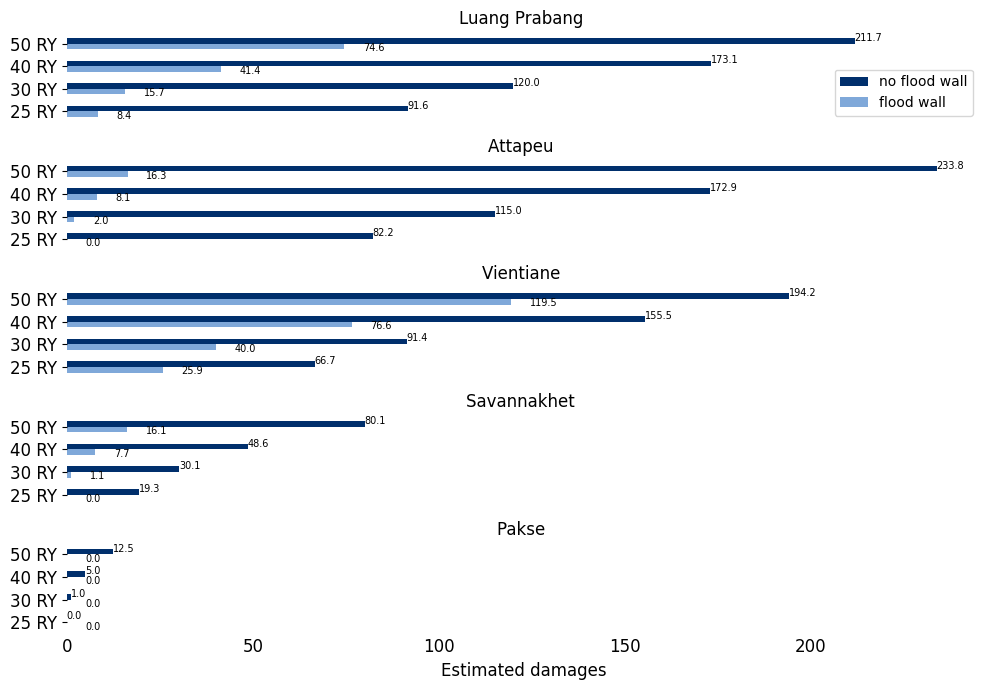

In [110]:
fig, axes = plt.subplots(5,1, figsize = (10,7), sharex= True )

re_dict = {'2025_fw': 'flood wall', '2025_no_fw': 'no flood wall'}

label_offset = 0
vertical_offset = 0

cities_1 = list(['Luang Prabang', 'Attapeu', 'Vientiane', 'Savannakhet', 'Pakse'])
for city, m in zip(cities_1, range(0,6)):
    for a,b, n, year in zip( ['flood wall' ] ,  ['no flood wall' ], range(0,2), ['2045'], ):

        data = (retunr_year_tables_cities['fw'][city].rename(
                columns = re_dict)[[a]].join( retunr_year_tables_cities['no_fw'][city].rename(
                columns = re_dict)[b] )).head().tail(4)

        # Invert columns order 
        data =  data.iloc[:, ::-1]
        
        bars = data.plot( kind = 'barh', ax = axes[m] , color = OECD_colors)
        
        axes[m].invert_yaxis()
        axes[m].set_title(f'{city} ')
        
        # hide legends
        if m > 0:
            axes[m].get_legend().remove()

            
    for bar_container, t, p in zip(bars.containers, [0,5], [0, -0.2 ]):
        for i, bar in enumerate(bar_container):
            width = bar.get_width()
            y_pos = bar.get_y() + bar.get_height() / 2 - p
            axes[m].text(width + (label_offset) + t , y_pos ,
                  f'{(width.round(1))}', fontsize= 7, color='black')

    # Set axis labels
    axes[m].set_ylabel('', fontsize=12)
    axes[m].set_xlabel('Estimated damages', fontsize=12)
    axes[m].tick_params(axis='both', which='major', labelsize=12)
    axes[m].tick_params(axis='x', which='both', length=0)

plt.tight_layout()
# fig.savefig(here("notebooks/final_paper/data/figures/flood_walls.png"));

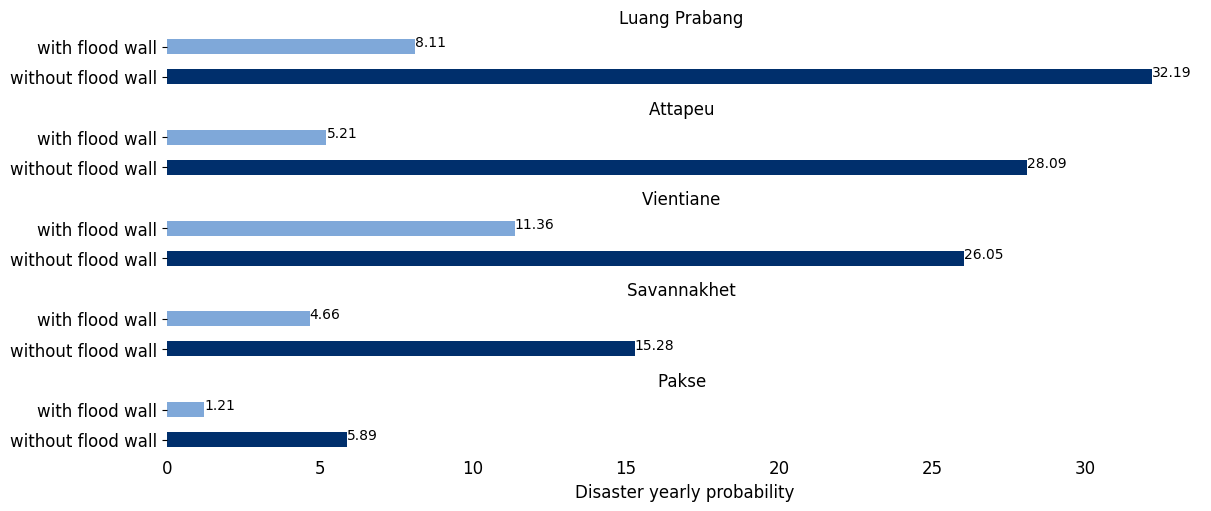

In [111]:
fig, axes = plt.subplots(5,1, figsize = (12,5), sharex= True )


label_offset = 0
vertical_offset = 0

for city, m in zip(cities_1, range(0,6)):
    for a,b, n, year in zip( ['flood wall' ] ,  ['no flood wall' ], range(0,2), ['2025']):

        bars = df_prob_changes.loc[city].plot( kind = 'barh', ax = axes[m] , color = OECD_colors )
        
        # axes[m].invert_yaxis()
        axes[m].set_title(f'{city} ')

            
    for bar_container, t in zip(bars.containers, [0, 0.1]):
        for i, bar in enumerate(bar_container):
            width = bar.get_width()
            y_pos = bar.get_y() + bar.get_height() / 2 + (i * vertical_offset)
            axes[m].text(width + label_offset +t , y_pos,
                  f'{(width.round(2))}', fontsize=10, color='black')

    # Set axis labels
    axes[m].set_xlabel('Disaster yearly probability', fontsize=12)
    axes[m].tick_params(axis='both', which='major', labelsize=12)
    axes[m].tick_params(axis='x', which='both', length=0)

# fig.savefig(here("notebooks/final_paper/data/figures/flood_walls_prob.png"));

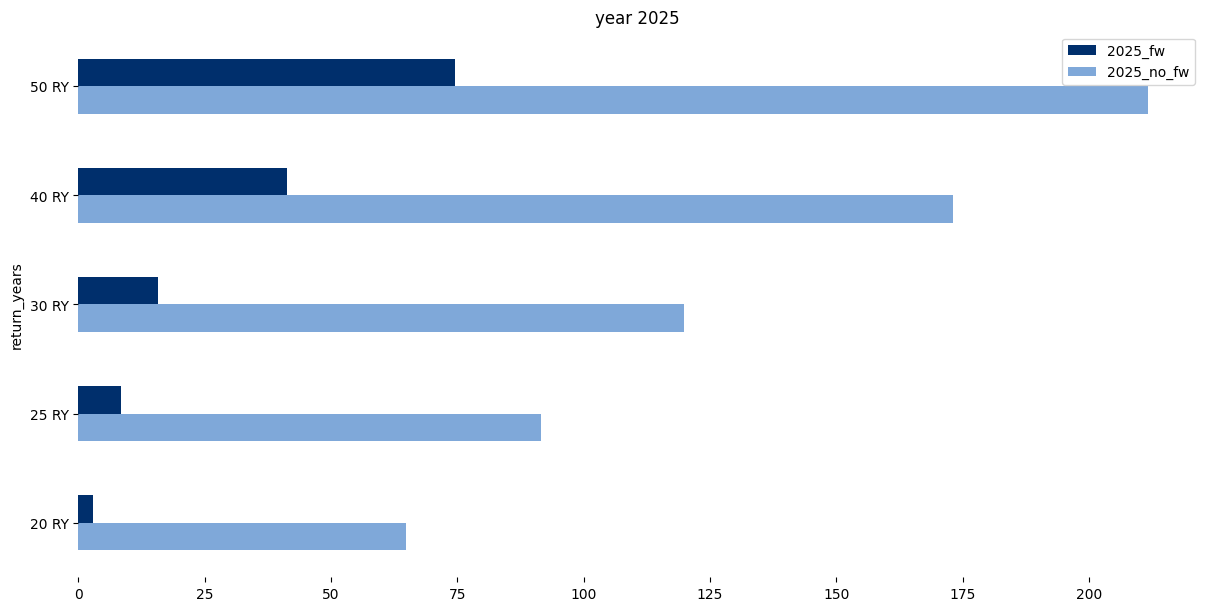

In [112]:
city = 'Luang Prabang'

fig, axes = plt.subplots(1,1, figsize = (12,6), sharey= True )
for a,b, n, year in zip( ['2025_fw' ] ,  ['2025_no_fw' ], range(0,2), ['2025']):
    data = retunr_year_tables_cities['fw'][city][[a]].join( retunr_year_tables_cities['no_fw'][city][b]).head(6).tail()
    data.plot(kind = 'barh', ax = axes )
    
    axes.invert_yaxis()
    axes.set_title(f'year {year} ')

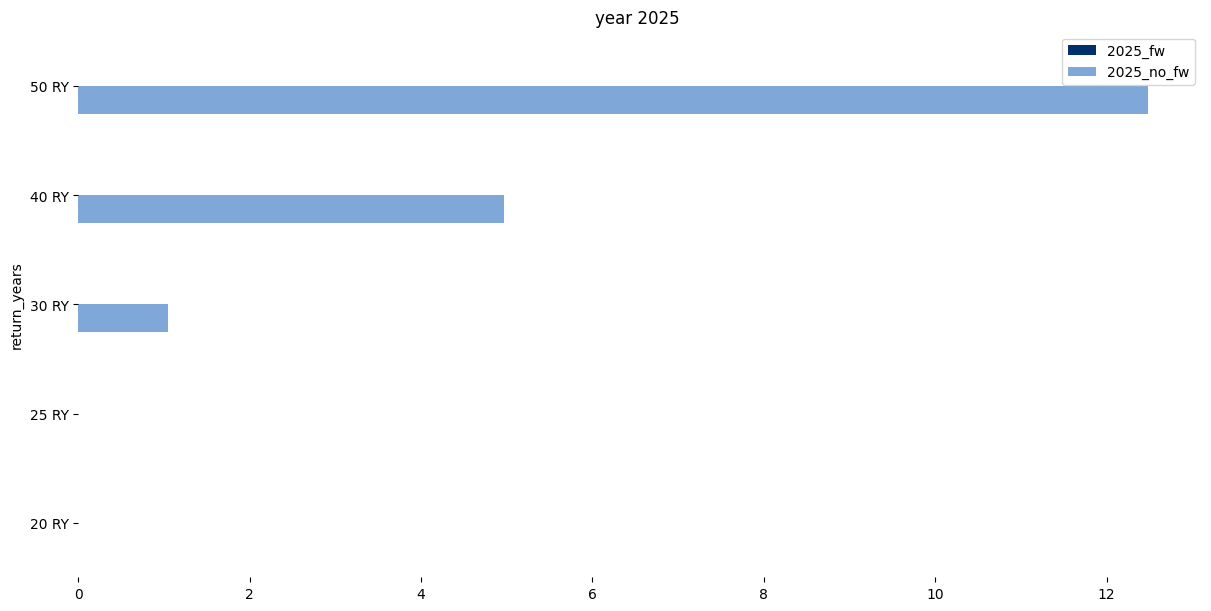

In [113]:
city = 'Pakse'

fig, axes = plt.subplots(1,1, figsize = (12,6), sharey= True )
for a,b, n, year in zip( ['2025_fw' ] ,  ['2025_no_fw' ], range(0,2), ['2025']):
    data = retunr_year_tables_cities['fw'][city][[a]].join( retunr_year_tables_cities['no_fw'][city][b]).head(6).tail()
    data.plot(kind = 'barh', ax = axes )
    
    axes.invert_yaxis()
    axes.set_title(f'year {year} ')